# Endangered Globe — Data Pipeline

Produces `animals.geojson`: one or more label Points per threatened species, with label, IUCN category, latest assessment metadata, and Wikipedia popularity.

The notebook starts in **sample mode** by default: it reads taxon IDs from the local IUCN spatial packages, then fetches IUCN Red List API v4 details only for those spatially relevant taxa. Switch to `RUN_MODE = "full_mammals"` for mammals, `RUN_MODE = "full_other"` for reptiles/amphibians/crustaceans, `RUN_MODE = "full_fish"` for sharks/rays/chimaeras and freshwater fish, or `RUN_MODE = "full_birds"` for birds.

**Steps**
1. Query latest global IUCN assessments for selected animal classes
2. Compute label points from IUCN habitat polygons or observation points
3. Wikidata SPARQL → Wikipedia article title
4. Wikimedia Pageviews API → 12-month view count
5. Assemble & export GeoJSON

In [51]:
# ── Dependencies ──────────────────────────────────────────────────────────────
# pip install requests pandas tqdm geopandas shapely

import importlib
import os, time, json, subprocess, sys
from pathlib import Path
from datetime import date

import requests
import pandas as pd
import geopandas as gpd
from tqdm.notebook import tqdm
from shapely.geometry import mapping
from shapely.ops import unary_union

import scripts.pipeline_helpers as ph
ph = importlib.reload(ph)
from scripts.pipeline_helpers import *


---
## 0 · Configuration

In [19]:
RUN_MODE = "sample_mammals"  # one of "sample_mammals", "sample_birds", "sample_fish", "sample_other", "full_mammals", "full_other", "full_fish", or "full_birds"

IUCN_TOKEN_FILE = Path("data/secrets/iucn_token.txt")
IUCN_TOKEN = os.getenv("IUCN_TOKEN") or read_local_secret(IUCN_TOKEN_FILE)  # Required for both sample and full modes
USER_AGENT = "EndangeredGlobe/1.0 (tdemareuil@gmail.com)"  # Wikimedia requires this

TARGET_CATEGORIES = ["EW", "CR", "EN", "VU", "NT", "CD"]  # CD → displayed as NT
SLEEP_WIKI = 0.25   # seconds between Wikimedia requests
SLEEP_IUCN = 0.5    # IUCN recommends >= 0.5s between calls

OUTPUT_PATH = f"data/processed/animals_{RUN_MODE}.geojson"
MERGED_OUTPUT_PATH = os.path.normpath(os.path.join(os.path.dirname(OUTPUT_PATH), "..", "..", "animals.geojson"))
DROPPED_LOG_PATH = f"data/processed/dropped_{RUN_MODE}.csv"
SPATIAL_DATA_DIR = "data/shapefiles"
BIRDS_FILTER_CSV = "data/filters/birds-filter-results.csv"
FULL_BIRDS_SIMPLIFIED = "data/processed/iucn_spatial_clean_full_birds_simplified.geojson"
if RUN_MODE.startswith("sample_"):
    _full_mode = RUN_MODE.replace("sample_", "full_", 1)
    _simplified = f"data/processed/iucn_spatial_clean_{_full_mode}_simplified.geojson"
    _full = f"data/processed/iucn_spatial_clean_{_full_mode}.geojson"
    if os.path.exists(_simplified):
        CLEAN_SPATIAL_OUTPUT_PATH = _simplified
    elif os.path.exists(_full):
        CLEAN_SPATIAL_OUTPUT_PATH = _full
    else:
        CLEAN_SPATIAL_OUTPUT_PATH = f"data/processed/iucn_spatial_clean_{RUN_MODE}.geojson"
else:
    CLEAN_SPATIAL_OUTPUT_PATH = f"data/processed/iucn_spatial_clean_{RUN_MODE}.geojson"
CLEAN_SPATIAL_SIMPLIFIED_PATH = f"data/processed/iucn_spatial_clean_{RUN_MODE}_simplified.geojson"
SIMPLIFY_TOLERANCE = 0.01  # degrees (~1 km); degrees (~1 km)
CLEAN_SPATIAL_TARGETS_PATH = f"data/processed/iucn_api_output_{RUN_MODE}.csv"
CLEAN_SPATIAL_PARENT_TARGETS_PATH = "data/processed/iucn_parent_spatial_fallback_taxa.csv"
CLEAN_SPATIAL_PARENT_OUTPUT_PATH = "data/processed/iucn_parent_spatial_fallback.geojson"
IUCN_RED_LIST_VERSION = "2025-2"  # Update if your spatial download uses another Red List version
IUCN_RED_LIST_VERSION_YEAR = "2025"
IUCN_DATA_LAST_UPDATED = "10 October 2025"
SPATIAL_DATA_DOWNLOAD_DATE = "14 June 2026"  # Update to the actual IUCN spatial download date
IUCN_DATASET_CITATION = f"IUCN {IUCN_RED_LIST_VERSION_YEAR}. The IUCN Red List of Threatened Species. Version {IUCN_RED_LIST_VERSION}. https://www.iucnredlist.org. Downloaded on {SPATIAL_DATA_DOWNLOAD_DATE}."
SAMPLE_LIMIT = 200
RUN_SPATIAL_CLEANING = True   # Set to False once iucn_spatial_clean.geojson exists
OVERWRITE_SPATIAL_CLEAN = False  # Set to True only when re-running from fresh raw shapefiles
RUN_IUCN_FETCH = True       # Set to False to reload df from saved CSV and skip the API
MAX_RANGE_CENTROIDS_PER_SPECIES = 2
RANGE_CLUSTER_BUFFER_KM = 200
SECONDARY_RANGE_CLUSTER_MIN_SHARE = 0.2
USE_IUCN_CACHE = True
USE_PARENT_SPATIAL_FALLBACK = False
GLOBAL_SCOPE_CODE = 1

dropped_log = []

ph.configure(
    IUCN_TOKEN=IUCN_TOKEN,
    USER_AGENT=USER_AGENT,
    TARGET_CATEGORIES=TARGET_CATEGORIES,
    SLEEP_WIKI=SLEEP_WIKI,
    SLEEP_IUCN=SLEEP_IUCN,
    SPATIAL_DATA_DIR=SPATIAL_DATA_DIR,
    SAMPLE_LIMIT=SAMPLE_LIMIT,
    USE_IUCN_CACHE=USE_IUCN_CACHE,
    USE_PARENT_SPATIAL_FALLBACK=USE_PARENT_SPATIAL_FALLBACK,
    BIRDS_FILTER_CSV=BIRDS_FILTER_CSV,
    GLOBAL_SCOPE_CODE=GLOBAL_SCOPE_CODE,
    IUCN_RED_LIST_VERSION=IUCN_RED_LIST_VERSION,
    IUCN_DATASET_CITATION=IUCN_DATASET_CITATION,
    SPATIAL_DATA_DOWNLOAD_DATE=SPATIAL_DATA_DOWNLOAD_DATE,
    IUCN_DATA_LAST_UPDATED=IUCN_DATA_LAST_UPDATED,
)


### Spatial cleaning

Reads the raw spatial files once, filters to threatened species, applies presence/seasonal filtering, and writes `iucn_spatial_clean_[mode].geojson`:
- **Birds**: keeps only taxa listed in the BirdLife filter CSV.
- **All other packages**: keeps only rows with a displayable IUCN category in the shapefile.

Set `RUN_SPATIAL_CLEANING = False` once the file exists and the raw data hasn't changed.

In [3]:
packages = RUN_MODE_SPATIAL_PACKAGES[RUN_MODE]

if RUN_MODE.startswith("sample_") and CLEAN_SPATIAL_OUTPUT_PATH != f"data/processed/iucn_spatial_clean_{RUN_MODE}.geojson":
    print(f"{RUN_MODE}: reusing {CLEAN_SPATIAL_OUTPUT_PATH}")
elif RUN_SPATIAL_CLEANING:
    if os.path.exists(CLEAN_SPATIAL_OUTPUT_PATH) and not OVERWRITE_SPATIAL_CLEAN:
        print(f"Clean file already exists — skipping to protect it (set OVERWRITE_SPATIAL_CLEAN=True to overwrite): {CLEAN_SPATIAL_OUTPUT_PATH}")
    else:
        ph.run_spatial_prefilter(
            packages=packages,
            output_path=CLEAN_SPATIAL_OUTPUT_PATH,
            birds_filter_csv=BIRDS_FILTER_CSV if "BIRDS" in packages else None,
        )
else:
    print(f"Using existing clean spatial file: {CLEAN_SPATIAL_OUTPUT_PATH}")

sample_mammals: reusing data/processed/iucn_spatial_clean_full_mammals_simplified.geojson


### Geometry simplification

Spatial files can be several GB. Since only centroids are needed downstream, geometries are simplified to `SIMPLIFY_TOLERANCE` degrees (~1 km) and written to a separate `_simplified` file. All `full_*` modes run this step. `sample_*` modes skip it and reuse the corresponding `full_*` simplified file.

In [ ]:
# Determine source and output paths for simplification
if RUN_MODE.startswith('sample_'):
    _full_mode = RUN_MODE.replace('sample_', 'full_', 1)
    _simplify_input  = f"data/processed/iucn_spatial_clean_{_full_mode}.geojson"
    _simplify_output = f"data/processed/iucn_spatial_clean_{_full_mode}_simplified.geojson"
else:
    _simplify_input  = CLEAN_SPATIAL_OUTPUT_PATH
    _simplify_output = CLEAN_SPATIAL_SIMPLIFIED_PATH

if not os.path.exists(_simplify_input):
    print(f"Simplification skipped — source file not found: {_simplify_input}")
elif os.path.exists(_simplify_output) and not OVERWRITE_SPATIAL_CLEAN:
    print(f"Simplified file already exists — skipping (set OVERWRITE_SPATIAL_CLEAN=True to redo): {_simplify_output}")
else:
    import geopandas as gpd
    os.environ['OGR_GEOJSON_MAX_OBJ_SIZE'] = '0'
    before_size = os.path.getsize(_simplify_input) / 1e6
    print(f"Loading {_simplify_input} ({before_size:.0f} MB) for simplification...")
    gdf = gpd.read_file(_simplify_input)
    gdf['geometry'] = gdf.geometry.simplify(SIMPLIFY_TOLERANCE, preserve_topology=True)
    gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty].copy()
    gdf.to_file(_simplify_output, driver='GeoJSON')
    after_size = os.path.getsize(_simplify_output) / 1e6
    print(f"Simplified: {before_size:.0f} MB → {after_size:.0f} MB ({after_size/before_size*100:.1f}%)")
    print(f"Written: {_simplify_output}")

Simplified file already exists — skipping (set OVERWRITE_SPATIAL_CLEAN=True to redo): data/processed/iucn_spatial_clean_full_mammals_simplified.geojson


---
## 1 · Species list

Default sample path: read mammal taxon IDs from the local mammal spatial package, then fetch a small IUCN detail set so test runs stay quick.

Mammal full path: set `RUN_MODE = "full_mammals"` to process taxa present in the local mammal spatial package.

Other full path: set `RUN_MODE = "full_other"` to process taxa present in the local Reptilia, Amphibia, and selected crustacean spatial packages.

Fish full path: set `RUN_MODE = "full_fish"` to process taxa present in the local freshwater fish and sharks/rays/chimaeras spatial packages, without querying broad marine fish classes.

Subspecies nuance: only shapefile taxa with endangered spatial categories are fetched from the API. If one of those fetched/displayable parent species reports threatened infrarank children that are absent from the shapefiles, those children can be displayed while inheriting the parent species geometry as a lookup source.

Ignored edge case for speed and simplicity: a non-threatened parent species whose missing infrarank child is threatened and absent from the shapefiles. We do not fetch LC/DD/NE parent taxa just to search for this case.


### IUCN API call

In [11]:
if not RUN_IUCN_FETCH and os.path.exists(CLEAN_SPATIAL_TARGETS_PATH):
    df = pd.read_csv(CLEAN_SPATIAL_TARGETS_PATH)
    print(f"Loaded {len(df):,} taxa from {CLEAN_SPATIAL_TARGETS_PATH} (API fetch skipped)")
else:
    spatial_manifest = ph.spatial_manifest_from_clean_file(CLEAN_SPATIAL_OUTPUT_PATH, RUN_MODE)
    df = fetch_iucn_species_from_spatial_manifest(spatial_manifest)
    print(f"{RUN_MODE} mode before dedup: {len(df):,} display taxa from IUCN")

df.head()
# Track taxa seeded from spatial manifest but not retained after IUCN fetch + selection
if RUN_IUCN_FETCH and 'spatial_manifest' in dir():
    _seeded_ids = set(spatial_manifest["taxonid"].astype(int))
    ph.log_dropped(dropped_log, _seeded_ids, df["taxonid"].astype(int), "iucn_api_fetch",
                "not fetched or not displayable (wrong category, no assessment, or filtered)", df)
    print(f"  dropped_log total: {len(dropped_log)} taxa")


Spatial manifest from clean file: 200 taxa (sample_mammals)


Fetch IUCN from spatial IDs:   0%|          | 0/200 [00:00<?, ?it/s]

IUCN spatial-package fetch summary
- Spatial seed taxa fetched from API: 200
- Display rows kept: 200 (200 direct shapefile taxa + 0 children using parent geometry)
- Missing-spatial child candidates tested from displayable parents: 0
- Missing-spatial children added with parent geometry: 0
- Parent rows not used for child discovery after API validation: 0
- Self rows skipped by shapefile category prefilter: 0
- Child/self rows skipped after API detail: 0 (none)
- Duplicate rows ignored: 0
sample_mammals mode before dedup: 200 display taxa from IUCN
  dropped_log total: 0 taxa


### Species vs. subspecies selection

In [12]:
if RUN_IUCN_FETCH:
    # Parent species removed here are not displayed, but child rows keep parent_taxonid
    # and spatial_lookup_taxonid so later spatial/Wikidata fallbacks can still use the parent.
    print(f"Fetched rows: {len(df):,}; unique taxa: {df.taxonid.nunique():,}")
    
    if "spatial_lookup_source" in df.columns:
        print(df["spatial_lookup_source"].fillna("Unknown").value_counts().to_string())
    
    if {"category", "spatial_category", "spatial_lookup_source"}.issubset(df.columns):
        direct_rows = df[df["spatial_lookup_source"].eq("self")].copy()
        direct_mismatches = direct_rows[direct_rows["category"].fillna("Unknown") != direct_rows["spatial_category"].fillna("Unknown")]
        print(
            f"\nDirect shapefile taxa with API category different from shapefile category: "
            f"{len(direct_mismatches):,} / {len(direct_rows):,}"
        )
        if not direct_mismatches.empty:
            display(
                direct_mismatches[["taxonid", "scientific_name", "main_common_name", "category", "spatial_category"]]
                .head(20)
            )
    
    # Normalise CD -> NT for display, deduplicate on taxonid, then prefer fetched
    # endangered infraranks over their parent species.
    df["category_iucn"] = df["category"].replace("CD", "NT")
    df = df.drop_duplicates(subset="taxonid").copy()
    before_selection = len(df)
    df = replace_species_with_available_infraranks(df)
    removed_parents = before_selection - len(df)
    print(f"\nAfter species vs. subspecies selection: {len(df):,} rows ({removed_parents:,} parent species removed)")
    
    print("\nEndangered category balance after selection:")
    print(df["category_iucn"].value_counts().to_string())
    if "taxon_rank" in df.columns:
        print("\ntaxon_rank after selection:")
        print(df["taxon_rank"].fillna("Unknown").value_counts().to_string())
    if "taxon_group" in df.columns:
        print("\ntaxon_group after selection:")
        print(df["taxon_group"].fillna("Unknown").value_counts().to_string())
    
    df.head()
else:
    print(f"Species/subspecies selection skipped — using saved CSV ({df['taxon_rank'].value_counts().to_string() if 'taxon_rank' in df.columns else ''})")

Fetched rows: 200; unique taxa: 200
spatial_lookup_source
self    200

Direct shapefile taxa with API category different from shapefile category: 0 / 200
Species vs. subspecies selection: 17 species list infrarank children, but no fetched/displayable child had an endangered category; parent species kept

After species vs. subspecies selection: 200 rows (0 parent species removed)

Endangered category balance after selection:
category_iucn
VU    63
EN    62
NT    49
CR    26

taxon_rank after selection:
taxon_rank
species    200

taxon_group after selection:
taxon_group
Mammals    200


### Save API output

In [13]:
os.makedirs(os.path.dirname(CLEAN_SPATIAL_TARGETS_PATH), exist_ok=True)
df.to_csv(CLEAN_SPATIAL_TARGETS_PATH, index=False)
print(f"API output saved: {CLEAN_SPATIAL_TARGETS_PATH} ({len(df):,} rows, {len(df.columns)} columns)")

API output saved: data/processed/iucn_api_output_sample_mammals.csv (200 rows, 25 columns)


---
## 2 · IUCN Spatial Data — habitat polygons / observation points → centroids

All run modes use the same spatial step. The difference is which local IUCN spatial packages seed `df`. The heavy source files are cleaned in the previous cell; this section reads the smaller cleaned spatial file.

Rules:
- If a species has one contiguous range polygon, use a centroid-like point inside that shape.
- If a species has multiple disjoint range polygons, group nearby components with the configured `RANGE_CLUSTER_BUFFER_KM`, always keep the largest cluster, then keep secondary clusters only when they pass `SECONDARY_RANGE_CLUSTER_MIN_SHARE`, capped by `MAX_RANGE_CENTROIDS_PER_SPECIES`.
- If a species has no range polygon, fall back to the centroid of its observation points.

Download the relevant animal shapefiles from [IUCN Spatial Data Download](https://www.iucnredlist.org/resources/spatial-data-download) into `data/shapefiles/` before running the cleaning step.

Matching method:
- IUCN API rows use `taxonid` as the species/taxon identifier.
- IUCN spatial files use `id_no` for the same identifier.
- Therefore the spatial join is `spatial.id_no == df.taxonid`, not `assessment_id`.
- Spatial source folders are selected from explicit `spatial_package` values; `taxon_class` is kept only as API metadata.
- This keeps package concepts separate from taxonomy concepts: for example, `FW_FISH` is not the same thing as the whole class `Actinopterygii`.
- Split downloads such as `MAMMALS_PART*.shp` and `FW_FISH_PART*.shp` are chunks of the same spatial package; concatenate them, filter to target `taxonid`s, then dissolve/group by `taxonid`.
- Use `presence` as a strong priority per taxon: Extant, Probably Extant, Possibly Extant, Possibly Extinct, Presence Uncertain, Extinct.
- Ignore `origin` for centroid placement.
- Use `seasonal` as a secondary soft priority per taxon: Resident, then Breeding, then Non-breeding, then Passage, then Seasonality Uncertain.


In [14]:
# Load file
os.environ["OGR_GEOJSON_MAX_OBJ_SIZE"] = "0"
# Quick re-filter: keep only taxa confirmed by the IUCN API
target_ids = set(df["taxonid"].astype(int))
spatial_path = CLEAN_SPATIAL_SIMPLIFIED_PATH if os.path.exists(CLEAN_SPATIAL_SIMPLIFIED_PATH) else CLEAN_SPATIAL_OUTPUT_PATH
print(f"Loading spatial file: {spatial_path}")
gdf_all = load_clean_spatial_file(spatial_path)
gdf_all = gdf_all[gdf_all["taxonid"].astype(int).isin(target_ids)].copy()
gdf_all["spatial_lookup_taxonid"] = gdf_all["taxonid"].astype(int)
gdf_all["spatial_lookup_source"] = "self"
_ids_with_geometry = set(gdf_all["taxonid"].astype(int))
ph.log_dropped(dropped_log, target_ids, _ids_with_geometry, "spatial_join",
            "no spatial geometry in clean file", df)
print(f"  dropped_log total: {len(dropped_log)} taxa")


Loading spatial file: data/processed/iucn_spatial_clean_full_mammals_simplified.geojson
  dropped_log total: 0 taxa


### Parent species spatial fallback

This cell looks only at parent species from which spatial information will be propagated to displayed subspecies that were not initially present in the spatial files.

Parents remain lookup sources, never additional displayed animals. The fallback is deliberately narrow: it only applies to rows already routed to parent geometry during the IUCN fetch, then copies matched parent polygons/points onto those displayed subspecies.


In [15]:
if USE_PARENT_SPATIAL_FALLBACK:
    # Parent-species spatial fallback. This intentionally runs after the self-geometry load:
    # we only clean parent geometries for rows already routed to parent geometry in section 1.
    # Parents remain lookup sources, never displayed taxa.
    display_taxa = df.drop_duplicates(subset="taxonid").copy()
    display_taxa["taxonid"] = display_taxa["taxonid"].astype(int)
    display_taxa["parent_taxonid_numeric"] = pd.to_numeric(display_taxa.get("parent_taxonid"), errors="coerce")
    uses_parent_lookup = display_taxa.get("spatial_lookup_source").eq("parent_species") if "spatial_lookup_source" in display_taxa.columns else pd.Series(False, index=display_taxa.index)
    if "spatial_lookup_taxonid" in display_taxa.columns:
        parent_lookup_from_fetch = pd.to_numeric(display_taxa["spatial_lookup_taxonid"], errors="coerce")
        display_taxa.loc[display_taxa["parent_taxonid_numeric"].isna() & uses_parent_lookup, "parent_taxonid_numeric"] = parent_lookup_from_fetch
    self_spatial_taxa = set(gdf_all["taxonid"].astype(int))
    parent_fallback_links = display_taxa[
        display_taxa["parent_taxonid_numeric"].notna()
        & uses_parent_lookup
        & ~display_taxa["taxonid"].isin(self_spatial_taxa)
    ][["taxonid", "parent_taxonid_numeric", "spatial_package"]].drop_duplicates()
    
    if parent_fallback_links.empty:
        pass
    else:
        parent_fallback_links["parent_taxonid"] = parent_fallback_links["parent_taxonid_numeric"].astype(int)
        parent_ids = sorted(parent_fallback_links["parent_taxonid"].unique())
        parent_targets = (
            parent_fallback_links[["parent_taxonid", "spatial_package"]]
            .drop_duplicates()
            .rename(columns={"parent_taxonid": "taxonid"})
        )
        parent_targets["category_iucn"] = None
        parent_targets["scientific_name"] = None
        parent_targets = parent_targets[["taxonid", "spatial_package", "category_iucn", "scientific_name"]]
        parent_targets.to_csv(CLEAN_SPATIAL_PARENT_TARGETS_PATH, index=False)
    
        parent_cleaning_available = os.path.exists(CLEAN_SPATIAL_PARENT_OUTPUT_PATH)
        if RUN_SPATIAL_CLEANING:
            parent_cleaning_available = False
            try:
                run_spatial_cleaning(CLEAN_SPATIAL_PARENT_TARGETS_PATH, CLEAN_SPATIAL_PARENT_OUTPUT_PATH, SPATIAL_DATA_DIR)
                parent_cleaning_available = True
            except subprocess.CalledProcessError:
                print("Spatial parent fallback: parent cleaning found no usable records or failed; continuing without parent geometries")
        else:
            print(f"Skipping parent spatial cleaning; expecting existing file: {CLEAN_SPATIAL_PARENT_OUTPUT_PATH}")
    
        if parent_cleaning_available and os.path.exists(CLEAN_SPATIAL_PARENT_OUTPUT_PATH):
            parent_gdf = load_clean_spatial_file(CLEAN_SPATIAL_PARENT_OUTPUT_PATH, parent_ids)
            fallback_frames = []
            for link in parent_fallback_links.itertuples(index=False):
                parent_id = int(link.parent_taxonid)
                child_id = int(link.taxonid)
                parent_rows = parent_gdf[parent_gdf["taxonid"].astype(int) == parent_id].copy()
                if parent_rows.empty:
                    continue
                parent_rows["spatial_lookup_taxonid"] = parent_id
                parent_rows["spatial_lookup_source"] = "parent_species"
                parent_rows["taxonid"] = child_id
                fallback_frames.append(parent_rows)
            if fallback_frames:
                fallback_gdf = gpd.GeoDataFrame(pd.concat(fallback_frames, ignore_index=True), geometry="geometry", crs="EPSG:4326")
                gdf_all = gpd.GeoDataFrame(pd.concat([gdf_all, fallback_gdf], ignore_index=True), geometry="geometry", crs="EPSG:4326")
            else:
                pass


### Compute label points per species from polygons first, then observation points

In [20]:
if gdf_all.empty:
    raise RuntimeError("No spatial records matched. Check the cleaning output and IUCN taxon IDs.")

gdf_all["taxonid"] = gdf_all["taxonid"].astype(int)

polygon_rows = []
point_rows = []
for row in gdf_all.itertuples(index=False):
    for geom in polygon_parts(row.geometry):
        polygon_rows.append({"taxonid": row.taxonid, "geometry": geom, "source_path": row.source_path, "spatial_citation": row.spatial_citation, "spatial_year": row.spatial_year, "spatial_presence": getattr(row, "spatial_presence", None), "spatial_seasonal": getattr(row, "spatial_seasonal", None), "spatial_lookup_taxonid": getattr(row, "spatial_lookup_taxonid", row.taxonid), "spatial_lookup_source": getattr(row, "spatial_lookup_source", "self")})
    for geom in point_parts(row.geometry):
        point_rows.append({"taxonid": row.taxonid, "geometry": geom, "source_path": row.source_path, "spatial_citation": row.spatial_citation, "spatial_year": row.spatial_year, "spatial_presence": getattr(row, "spatial_presence", None), "spatial_seasonal": getattr(row, "spatial_seasonal", None), "spatial_lookup_taxonid": getattr(row, "spatial_lookup_taxonid", row.taxonid), "spatial_lookup_source": getattr(row, "spatial_lookup_source", "self")})

polygon_gdf = gpd.GeoDataFrame(polygon_rows, geometry="geometry", crs="EPSG:4326") if polygon_rows else gpd.GeoDataFrame(columns=["taxonid", "geometry", "source_path", "spatial_citation", "spatial_year", "spatial_presence", "spatial_seasonal", "spatial_lookup_taxonid", "spatial_lookup_source"], geometry="geometry", crs="EPSG:4326")
point_gdf = gpd.GeoDataFrame(point_rows, geometry="geometry", crs="EPSG:4326") if point_rows else gpd.GeoDataFrame(columns=["taxonid", "geometry", "source_path", "spatial_citation", "spatial_year", "spatial_presence", "spatial_seasonal", "spatial_lookup_taxonid", "spatial_lookup_source"], geometry="geometry", crs="EPSG:4326")

polygon_gdf = best_presence_records(polygon_gdf)
polygon_gdf = best_seasonal_records(polygon_gdf)
point_gdf = best_presence_records(point_gdf)
point_gdf = best_seasonal_records(point_gdf)


spatial_meta = (
    gdf_all.groupby("taxonid", as_index=False)
    .agg(
        source_paths=("source_path", lambda s: "; ".join(sorted({str(x) for x in s if pd.notna(x)}))),
        spatial_citation=("spatial_citation", first_non_empty),
        spatial_year=("spatial_year", latest_year),
    )
)
spatial_meta["iucn_dataset_citation"] = IUCN_DATASET_CITATION
spatial_meta["iucn_data_last_updated"] = IUCN_DATA_LAST_UPDATED
spatial_meta["spatial_credit"] = spatial_meta.apply(lambda row: build_spatial_credit(row.spatial_citation, row.spatial_year), axis=1)

if not polygon_gdf.empty:
    polygon_gdf["geometry"] = polygon_gdf["geometry"].map(make_valid)
    polygon_gdf = polygon_gdf[polygon_gdf.geometry.notna() & ~polygon_gdf.geometry.is_empty].copy()
    range_geometries = polygon_gdf.dissolve(by="taxonid").reset_index()[["taxonid", "geometry"]]
    range_presence = polygon_gdf.groupby("taxonid", as_index=False).agg(spatial_presence=("spatial_presence", first_non_empty))
    range_seasons = polygon_gdf.groupby("taxonid", as_index=False).agg(spatial_seasonal=("spatial_seasonal", first_non_empty))
    range_lookup = polygon_gdf.groupby("taxonid", as_index=False).agg(spatial_lookup_taxonid=("spatial_lookup_taxonid", first_non_empty), spatial_lookup_source=("spatial_lookup_source", first_non_empty))
    range_geometries = range_geometries.merge(range_presence, on="taxonid", how="left")
    range_geometries = range_geometries.merge(range_seasons, on="taxonid", how="left")
    range_geometries = range_geometries.merge(range_lookup, on="taxonid", how="left")
    range_geometries["spatial_presence_label"] = range_geometries["spatial_presence"].map(presence_label)
    range_geometries["spatial_seasonal_label"] = range_geometries["spatial_seasonal"].map(seasonal_label)
else:
    range_geometries = gpd.GeoDataFrame(columns=["taxonid", "geometry", "spatial_presence", "spatial_presence_label", "spatial_seasonal", "spatial_seasonal_label", "spatial_lookup_taxonid", "spatial_lookup_source"], geometry="geometry", crs="EPSG:4326")

if not point_gdf.empty:
    point_geometries = point_gdf.dissolve(by="taxonid").reset_index()[["taxonid", "geometry"]]
    point_presence = point_gdf.groupby("taxonid", as_index=False).agg(spatial_presence=("spatial_presence", first_non_empty))
    point_seasons = point_gdf.groupby("taxonid", as_index=False).agg(spatial_seasonal=("spatial_seasonal", first_non_empty))
    point_lookup = point_gdf.groupby("taxonid", as_index=False).agg(spatial_lookup_taxonid=("spatial_lookup_taxonid", first_non_empty), spatial_lookup_source=("spatial_lookup_source", first_non_empty))
    point_geometries = point_geometries.merge(point_presence, on="taxonid", how="left")
    point_geometries = point_geometries.merge(point_seasons, on="taxonid", how="left")
    point_geometries = point_geometries.merge(point_lookup, on="taxonid", how="left")
    point_geometries["spatial_presence_label"] = point_geometries["spatial_presence"].map(presence_label)
    point_geometries["spatial_seasonal_label"] = point_geometries["spatial_seasonal"].map(seasonal_label)
else:
    point_geometries = gpd.GeoDataFrame(columns=["taxonid", "geometry", "spatial_presence", "spatial_presence_label", "spatial_seasonal", "spatial_seasonal_label", "spatial_lookup_taxonid", "spatial_lookup_source"], geometry="geometry", crs="EPSG:4326")


centroid_rows = []
polygon_taxa = set(range_geometries["taxonid"].astype(int)) if not range_geometries.empty else set()

for row in tqdm(range_geometries.itertuples(index=False), total=len(range_geometries), desc="Range polygon centroids"):
    parts = polygon_parts(row.geometry)
    if not parts:
        continue
    cluster_gdf = cluster_range_parts(parts, RANGE_CLUSTER_BUFFER_KM)
    total_components = len(parts)
    total_clusters = len(cluster_gdf)
    computed_range_area_km2 = float(cluster_gdf["cluster_area_km2"].sum())
    ranked_clusters = cluster_gdf.sort_values("cluster_area_km2", ascending=False).reset_index(drop=True)
    ranked_clusters["range_cluster_area_share"] = 0.0
    if computed_range_area_km2 > 0:
        ranked_clusters["range_cluster_area_share"] = ranked_clusters["cluster_area_km2"] / computed_range_area_km2
    top_clusters = ranked_clusters[
        (ranked_clusters.index == 0)
        | (ranked_clusters["range_cluster_area_share"] >= SECONDARY_RANGE_CLUSTER_MIN_SHARE)
    ].head(MAX_RANGE_CENTROIDS_PER_SPECIES)
    for rank, cluster in enumerate(top_clusters.itertuples(index=False), start=1):
        point = safe_centroid(cluster.geometry)
        centroid_rows.append({
            "taxonid": int(row.taxonid),
            "geometry": point,
            "lon": point.x,
            "lat": point.y,
            "centroid_source": "range_polygon",
            "centroid_rank": rank,
            "centroid_count": len(top_clusters),
            "range_component_count": total_components,
            "range_cluster_count": total_clusters,
            "range_cluster_component_count": cluster.cluster_component_count,
            "range_cluster_buffer_km": RANGE_CLUSTER_BUFFER_KM,
            "range_cluster_area_share": float(cluster.range_cluster_area_share),
            "spatial_presence": row.spatial_presence,
            "spatial_presence_label": row.spatial_presence_label,
            "spatial_seasonal": row.spatial_seasonal,
            "spatial_seasonal_label": row.spatial_seasonal_label,
            "spatial_lookup_taxonid": row.spatial_lookup_taxonid,
            "spatial_lookup_source": row.spatial_lookup_source,
            "computed_range_area_km2": computed_range_area_km2,
            "computed_range_component_area_km2": float(cluster.cluster_area_km2),
            "range_component_area_km2": float(cluster.cluster_area_km2),
            "observation_point_count": None,
        })

for row in tqdm(point_geometries.itertuples(index=False), total=len(point_geometries), desc="Fallback point centroids"):
    if int(row.taxonid) in polygon_taxa:
        continue
    points = point_parts(row.geometry)
    if not points:
        continue
    point = unary_union(points).centroid
    centroid_rows.append({
        "taxonid": int(row.taxonid),
        "geometry": point,
        "lon": point.x,
        "lat": point.y,
        "centroid_source": "observation_points",
        "centroid_rank": 1,
        "centroid_count": 1,
        "range_component_count": 0,
        "range_cluster_count": 0,
        "range_cluster_component_count": None,
        "range_cluster_buffer_km": None,
        "range_cluster_area_share": None,
        "spatial_presence": row.spatial_presence,
        "spatial_presence_label": row.spatial_presence_label,
        "spatial_seasonal": row.spatial_seasonal,
        "spatial_seasonal_label": row.spatial_seasonal_label,
        "spatial_lookup_taxonid": row.spatial_lookup_taxonid,
        "spatial_lookup_source": row.spatial_lookup_source,
        "computed_range_area_km2": None,
        "computed_range_component_area_km2": None,
        "range_component_area_km2": None,
        "observation_point_count": len(points),
    })

centroids = gpd.GeoDataFrame(centroid_rows, geometry="geometry", crs="EPSG:4326")
if centroids.empty:
    raise RuntimeError("No range polygons or observation points matched the selected IUCN taxon IDs.")

centroid_cols = [
    "taxonid", "lon", "lat", "centroid_source", "centroid_rank", "centroid_count",
    "range_component_count", "range_cluster_count", "range_cluster_component_count",
    "range_cluster_buffer_km", "range_cluster_area_share",
    "spatial_presence", "spatial_presence_label",
    "spatial_seasonal", "spatial_seasonal_label",
    "spatial_lookup_taxonid", "spatial_lookup_source",
    "computed_range_area_km2", "computed_range_component_area_km2",
    "range_component_area_km2", "observation_point_count",
]
spatial_meta_cols = [col for col in spatial_meta.columns if col != "taxonid"]
spatial_merge_cols = [col for col in centroid_cols if col != "taxonid"] + spatial_meta_cols
df["taxonid"] = df["taxonid"].astype(int)
df_base = df.drop(columns=spatial_merge_cols, errors="ignore").drop_duplicates(subset="taxonid").copy()
df = df_base.merge(centroids[centroid_cols], on="taxonid", how="inner")
df = df.merge(spatial_meta, on="taxonid", how="left")
ph.log_dropped(dropped_log, df_base["taxonid"].astype(int), df["taxonid"].astype(int),
            "centroid_merge", "no centroid computed (no polygon or point geometry matched)", df_base)
print(f"  dropped_log total: {len(dropped_log)} taxa")
print(f"Output label points with spatial data: {len(df):,} from {df.taxonid.nunique():,} species")
secondary = df[df["centroid_rank"].fillna(1).astype(int) > 1]
print(f"Of which, secondary centroid points kept: {len(secondary):,}")


Range polygon centroids:   0%|          | 0/200 [00:00<?, ?it/s]

Fallback point centroids: 0it [00:00, ?it/s]

  dropped_log total: 0 taxa
Output label points with spatial data: 211 from 200 species
Of which, secondary centroid points kept: 11


In [21]:
df.shape

(211, 49)

### Explore taxa that produced several spatial label points

Taxa with several label points: 11


,taxonid,scientific_name,main_common_name,category_iucn,label_points,source,selected_presence,selected_season,components_available,clusters_available,cluster_buffer_km,total_range_area_km2
93,3590,Callorhinus ursinus,Northern Fur Seal,VU,2,range_polygon,Extant,Resident,2,2,200,1.694793e+07
6,219,Acinonyx jubatus,Cheetah,VU,2,range_polygon,Extant,Resident,77,6,200,3.191571e+06
119,4141,Cephalophus leucogaster,White-bellied Duiker,NT,2,range_polygon,Extant,Resident,2,2,200,1.003452e+06
24,1151,Ammotragus lervia,Aoudad,VU,2,range_polygon,Extant,Resident,49,2,200,9.294205e+05
67,2828,Blastocerus dichotomus,Marsh Deer,VU,2,range_polygon,Extant,Resident,37,5,200,4.339841e+05
68,2888,Bos javanicus,Banteng,CR,2,range_polygon,Extant,Resident,27,6,200,2.277190e+05
148,4265,Rucervus eldii,Eld's Deer,EN,2,range_polygon,Extant,Resident,19,3,200,8.370922e+04
7,512,Addax nasomaculatus,Addax,CR,2,range_polygon,Extant,Resident,4,2,200,3.354404e+04
185,5224,Conilurus penicillatus,Brush-tailed Rabbit-rat,VU,2,range_polygon,Extant,Resident,9,3,200,1.613861e+04
77,3129,Bubalus arnee,Wild Water Buffalo,EN,2,range_polygon,Extant,Resident,11,4,200,1.282884e+04


Exploring taxonid: 512


,taxonid,scientific_name,main_common_name,category_iucn,centroid_rank,centroid_count,centroid_source,lon,lat,computed_range_component_area_km2,computed_range_area_km2,range_component_count,range_cluster_count,range_cluster_component_count,range_cluster_buffer_km,range_cluster_area_share,spatial_presence_label,spatial_seasonal_label
8,512,Addax nasomaculatus,Addax,CR,1,2,range_polygon,12.682267,16.487847,26592.620271,33544.039672,4,2,3,200,0.792767,Extant,Resident
9,512,Addax nasomaculatus,Addax,CR,2,2,range_polygon,-9.776403,20.761544,6951.419401,33544.039672,4,2,1,200,0.207233,Extant,Resident


,cluster_rank,cluster_area_km2,range_cluster_area_share,cluster_component_count,selected_for_label
0,1,26592.620271,0.792767,3,True
1,2,6951.419401,0.207233,1,True


,taxonid,raw_polygon_area_km2,spatial_presence_label,spatial_seasonal_label,source_path
32,512,22802.998777,Extant,Resident,MAMMALS_PART1.shp
31,512,6951.419401,Extant,Resident,MAMMALS_PART1.shp
29,512,3066.862351,Extant,Resident,MAMMALS_PART1.shp
30,512,722.759143,Extant,Resident,MAMMALS_PART1.shp


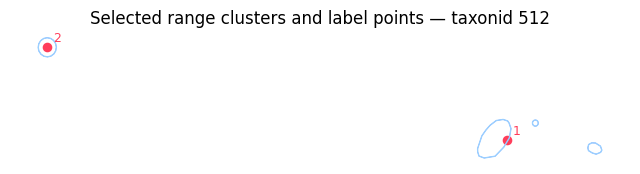

In [55]:
# Set EXPLORE_TAXONID to one taxonid from multi_centroid_summary, or leave None to inspect the first one.
EXPLORE_TAXONID = 512
SHOW_EXPLORE_MAP = True

explore_centroid_cols = [
    "taxonid", "lon", "lat", "centroid_source", "centroid_rank", "centroid_count",
    "range_component_count", "range_cluster_count", "range_cluster_component_count", "range_cluster_buffer_km", "range_cluster_area_share",
    "spatial_presence_label", "spatial_seasonal_label",
    "computed_range_area_km2", "computed_range_component_area_km2",
]
missing_centroid_cols = [col for col in explore_centroid_cols if col not in centroids.columns]
if missing_centroid_cols:
    raise RuntimeError(f"Run the spatial centroid cell before this exploration cell. Missing columns: {missing_centroid_cols}")

taxa_for_explore = df.drop(columns=[col for col in explore_centroid_cols if col != "taxonid"], errors="ignore").copy()
taxa_for_explore["taxonid"] = taxa_for_explore["taxonid"].astype(int)
taxa_for_explore = taxa_for_explore.drop_duplicates(subset="taxonid")
explore_df = taxa_for_explore.merge(centroids[explore_centroid_cols], on="taxonid", how="inner")

multi_centroid_summary = (
    explore_df.groupby(["taxonid", "scientific_name", "main_common_name", "category_iucn"], dropna=False)
    .agg(
        label_points=("centroid_rank", "count"),
        source=("centroid_source", first_non_empty),
        selected_presence=("spatial_presence_label", first_non_empty),
        selected_season=("spatial_seasonal_label", first_non_empty),
        components_available=("range_component_count", "max"),
        clusters_available=("range_cluster_count", "max"),
        cluster_buffer_km=("range_cluster_buffer_km", first_non_empty),
        total_range_area_km2=("computed_range_area_km2", "max"),
    )
    .reset_index()
    .query("label_points > 1")
    .sort_values(["label_points", "total_range_area_km2"], ascending=[False, False])
)

print(f"Taxa with several label points: {len(multi_centroid_summary):,}")
display(multi_centroid_summary.head(25))

if multi_centroid_summary.empty:
    print("No taxa with several label points in the current sample.")
else:
    selected_taxonid = int(EXPLORE_TAXONID or multi_centroid_summary.iloc[0].taxonid)
    print(f"Exploring taxonid: {selected_taxonid}")

    selected_points = (
        explore_df[explore_df["taxonid"].astype(int) == selected_taxonid]
        .sort_values("centroid_rank")
        [[
            "taxonid", "scientific_name", "main_common_name", "category_iucn",
            "centroid_rank", "centroid_count", "centroid_source", "lon", "lat",
            "computed_range_component_area_km2", "computed_range_area_km2",
            "range_component_count", "range_cluster_count", "range_cluster_component_count", "range_cluster_buffer_km", "range_cluster_area_share",
            "spatial_presence_label", "spatial_seasonal_label",
        ]]
    )
    display(selected_points)

    selected_centroid_geoms = centroids[centroids["taxonid"].astype(int) == selected_taxonid].sort_values("centroid_rank")
    selected_range_geom = range_geometries[range_geometries["taxonid"].astype(int) == selected_taxonid]
    selected_clusters = gpd.GeoDataFrame(columns=["cluster_rank", "cluster_area_km2", "range_cluster_area_share", "cluster_component_count", "selected_for_label", "geometry"], geometry="geometry", crs="EPSG:4326")
    if not selected_range_geom.empty:
        selected_parts = polygon_parts(selected_range_geom.iloc[0].geometry)
        if selected_parts:
            selected_clusters = cluster_range_parts(selected_parts, RANGE_CLUSTER_BUFFER_KM).sort_values("cluster_area_km2", ascending=False).reset_index(drop=True)
            selected_clusters["cluster_rank"] = selected_clusters.index + 1
            selected_total_area = selected_clusters["cluster_area_km2"].sum()
            selected_clusters["range_cluster_area_share"] = 0.0
            if selected_total_area > 0:
                selected_clusters["range_cluster_area_share"] = selected_clusters["cluster_area_km2"] / selected_total_area
            selected_clusters["selected_for_label"] = (
                (selected_clusters["cluster_rank"] == 1)
                | (
                    (selected_clusters["cluster_rank"] <= MAX_RANGE_CENTROIDS_PER_SPECIES)
                    & (selected_clusters["range_cluster_area_share"] >= SECONDARY_RANGE_CLUSTER_MIN_SHARE)
                )
            )
            display(selected_clusters[["cluster_rank", "cluster_area_km2", "range_cluster_area_share", "cluster_component_count", "selected_for_label"]].head(30))
    selected_raw_polygons = polygon_gdf[polygon_gdf["taxonid"].astype(int) == selected_taxonid].copy()
    if not selected_raw_polygons.empty:
        selected_raw_polygons = selected_raw_polygons.copy()
        selected_raw_polygons["raw_polygon_area_km2"] = selected_raw_polygons.to_crs(6933).area / 1e6
        display(
            selected_raw_polygons
            .assign(
                spatial_presence_label=lambda d: d["spatial_presence"].map(presence_label),
                spatial_seasonal_label=lambda d: d["spatial_seasonal"].map(seasonal_label),
            )
            .sort_values("raw_polygon_area_km2", ascending=False)
            [["taxonid", "raw_polygon_area_km2", "spatial_presence_label", "spatial_seasonal_label", "source_path"]]
            .head(30)
        )

    if SHOW_EXPLORE_MAP:
        ax = selected_range_geom.boundary.plot(figsize=(8, 5), color="#4b6fff", linewidth=0.45)
        if not selected_clusters.empty:
            selected_clusters.boundary.plot(ax=ax, color="#9bd0ff", linewidth=1.0)
        selected_centroid_geoms.plot(ax=ax, color="#ff3d5a", markersize=35)
        for row in selected_centroid_geoms.itertuples(index=False):
            ax.annotate(str(row.centroid_rank), (row.lon, row.lat), xytext=(4, 4), textcoords="offset points", color="#ff3d5a", fontsize=9)
        ax.set_title(f"Selected range clusters and label points — taxonid {selected_taxonid}")
        ax.set_axis_off()


In [24]:
df.shape

(211, 49)

---
## 3 · Wikidata SPARQL — IUCN ID → Wikipedia article title

Both modes query Wikidata from IUCN taxon IDs. In sample mode, the batch is simply much smaller.

In [25]:
print("Wikidata language priority:", ", ".join(WIKIPEDIA_LANGUAGE_PRIORITY))


Wikidata language priority: en, de, ja, fr, es, ru, it, zh, pt, pl, nl, uk, ca, sv, cs, fi, ko, tr, no, da, eo


In [26]:
wikidata_taxon_ids = df["taxonid"].drop_duplicates().tolist()
wikidata_map = query_wikidata_batch(wikidata_taxon_ids)

# Name-based fallback: taxa whose IUCN taxon ID isn't linked in Wikidata
# (e.g. Catopuma temminckii stored as Pardofelis temminckii, or missing P627)
unresolved_ids = [t for t in wikidata_taxon_ids if str(t) not in wikidata_map]
if unresolved_ids:
    name_fallback = ph.query_wikidata_by_names(unresolved_ids, df)
    wikidata_map.update(name_fallback)

ph.configure(wikidata_map=wikidata_map)
print(f"Wikipedia articles found: {len(wikidata_map):,} / {len(wikidata_taxon_ids):,} taxa")
print(f"Raw Wikidata P18 images found before map-image filtering: {sum(1 for item in wikidata_map.values() if item.get('wikidata_image_url')):,}")
pd.Series([item.get("wiki_language") for item in wikidata_map.values()]).value_counts().head(10)


Wikidata batches:   0%|          | 0/1 [00:00<?, ?it/s]

Wikidata name fallback: 3 unresolved taxa → 3 P225 candidates
  [1/3] Neomicroxus latebricola ... found
  [2/3] Catopuma badia ... found
  [3/3] Catopuma temminckii ... found
  Resolved:
    Neomicroxus latebricola  →  Ecuadorian_grass_mouse  |  https://www.wikidata.org/entity/Q305746  |  https://en.wikipedia.org/wiki/Ecuadorian_grass_mouse
    Catopuma badia  →  Bay_cat  |  https://www.wikidata.org/entity/Q213044  |  https://en.wikipedia.org/wiki/Bay_cat
    Catopuma temminckii  →  Asian_golden_cat  |  https://www.wikidata.org/entity/Q192233  |  https://en.wikipedia.org/wiki/Asian_golden_cat
Wikipedia articles found: 200 / 200 taxa
Raw Wikidata P18 images found before map-image filtering: 154


en    199
fr      1
Name: count, dtype: int64

### Parent species Wikidata fallback

Wikipedia coverage is often at species level even when IUCN assesses a threatened subspecies. To avoid dropping those subspecies just because Wikidata/Wikipedia has no infrarank article, the notebook uses a parent-species lookup only when needed.

The displayed taxon stays the infrarank taxon: IUCN status, name, assessment URL, and spatial point remain tied to the displayed row. Only the article/image/pageviews lookup can be inherited from the parent. Parent IDs are queried only if they are missing from the local Wikidata cache, and the parent is never added as a displayed animal.

Rows using a parent article or pageview signal are marked with `wiki_lookup_source = "parent_species"`. Rows using only a parent image are marked separately with `image_lookup_source = "parent_species"`.


In [27]:
# Attach wiki title and Wikidata P18 image.
# If an infrarank taxon has no Wikipedia article, use its parent species as the
# Wikidata/Wikipedia/pageviews/image lookup source while keeping the displayed
# IUCN taxon and conservation status unchanged.
df["wiki_lookup_taxonid"] = df["taxonid"].astype(int)
df["wiki_lookup_source"] = "self"
attach_wikidata_fields(df, wikidata_map)

parent_taxonid_numeric = pd.to_numeric(df.get("parent_taxonid"), errors="coerce")
missing_self_wiki = df["wiki_title"].isna() & parent_taxonid_numeric.notna()
parent_wiki_ids = sorted(parent_taxonid_numeric[missing_self_wiki].dropna().astype(int).unique())
parent_wiki_ids_to_query = [taxonid for taxonid in parent_wiki_ids if str(taxonid) not in wikidata_map]
if parent_wiki_ids_to_query:
    parent_wikidata_map = query_wikidata_batch(parent_wiki_ids_to_query)
    wikidata_map.update(parent_wikidata_map)

parent_has_wiki = parent_taxonid_numeric.map(lambda taxonid: bool((wikidata_map.get(str(int(taxonid))) or {}).get("wiki_title")) if pd.notna(taxonid) else False)
parent_wiki_fallback = missing_self_wiki & parent_has_wiki
if parent_wiki_fallback.any():
    df.loc[parent_wiki_fallback, "wiki_lookup_taxonid"] = parent_taxonid_numeric[parent_wiki_fallback].astype(int)
    df.loc[parent_wiki_fallback, "wiki_lookup_source"] = "parent_species"
    attach_wikidata_fields(df, wikidata_map)

missing_wiki_taxa = (
    df[df["wiki_title"].isna()]
    .drop_duplicates(subset="taxonid")
    [["taxonid", "parent_taxonid", "scientific_name", "main_common_name", "category_iucn"]]
    .sort_values("taxonid")
)
_pre_wiki_ids = set(df["taxonid"].astype(int))
df_wiki = df.dropna(subset=["wiki_title"]).copy()
ph.log_dropped(dropped_log, _pre_wiki_ids, df_wiki["taxonid"].astype(int), "no_wikipedia",
            "no Wikipedia article found after all Wikidata + Wikipedia fallbacks", df)
print(f"  dropped_log total: {len(dropped_log)} taxa")
print(f"Rows with a Wikidata-resolved Wikipedia article: {len(df_wiki):,} label points from {df_wiki.taxonid.nunique():,} taxa")
print(f"Taxa using parent-species Wikipedia fallback: {df_wiki[df_wiki['wiki_lookup_source'] == 'parent_species'].taxonid.nunique():,}")
print(f"Taxa without a Wikidata-resolved Wikipedia article after parent fallback: {len(missing_wiki_taxa):,}")
display(missing_wiki_taxa.head(20))


  dropped_log total: 0 taxa
Rows with a Wikidata-resolved Wikipedia article: 211 label points from 200 taxa
Taxa using parent-species Wikipedia fallback: 0
Taxa without a Wikidata-resolved Wikipedia article after parent fallback: 0


,taxonid,parent_taxonid,scientific_name,main_common_name,category_iucn


In [28]:
df_wiki.shape

(211, 57)

In [29]:
# sanity check
df_wiki[df_wiki.scientific_name.str.contains("nictitans")]

,taxonid,assessment_id,assessment_date,year_published,iucn_assessment_url,iucn_citation,scientific_name,main_common_name,category,population_trend,...,iucn_data_last_updated,spatial_credit,wiki_lookup_taxonid,wiki_lookup_source,wiki_title,wiki_language,wiki_project,wiki_url,wikidata_url,wikidata_image_url
146,4224,222904443,2016-10-24T01:00:00.000+01:00,2020,https://www.iucnredlist.org/species/4224/22290...,"Cronin, D.T., Maisels, F., Gadsby, E.L., Goned...",Cercopithecus nictitans,Putty-nosed Monkey,NT,Decreasing,...,10 October 2025,IUCN (International Union for Conservation of ...,4224,self,Greater_spot-nosed_monkey,en,en.wikipedia.org,https://en.wikipedia.org/wiki/Greater_spot-nos...,https://www.wikidata.org/entity/Q1193818,https://commons.wikimedia.org/wiki/Special:Fil...


In [30]:
# sanity check
df_wiki[df_wiki.scientific_name.str.contains("latebricola")]

,taxonid,assessment_id,assessment_date,year_published,iucn_assessment_url,iucn_citation,scientific_name,main_common_name,category,population_trend,...,iucn_data_last_updated,spatial_credit,wiki_lookup_taxonid,wiki_lookup_source,wiki_title,wiki_language,wiki_project,wiki_url,wikidata_url,wikidata_image_url
13,741,22382354,2016-07-11T01:00:00.000+01:00,2019,https://www.iucnredlist.org/species/741/22382354,"Alvarado Serrano, D. 2019. Neomicroxus latebri...",Neomicroxus latebricola,Ecuadorean Grass Mouse,EN,Decreasing,...,10 October 2025,IUCN SSC Small Mammal Specialist Group 2019. T...,741,self,Ecuadorian_grass_mouse,en,en.wikipedia.org,https://en.wikipedia.org/wiki/Ecuadorian_grass...,https://www.wikidata.org/entity/Q305746,None


---
## 4 · Wikimedia Pageviews API — 12-month view count

Endpoint: `https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/{project}/{access}/{agent}/{article}/monthly/{start}/{end}`

We use the last 12 completed months and sum the monthly totals.

In [31]:
# Last 12 completed months. Wikimedia's monthly endpoint expects YYYYMMDD.
today = date.today()
current_month_start = date(today.year, today.month, 1)
start_month = date(current_month_start.year - 1, current_month_start.month, 1)
if current_month_start.month == 1:
    end_month = date(current_month_start.year - 1, 12, 1)
else:
    end_month = date(current_month_start.year, current_month_start.month - 1, 1)
START = start_month.strftime("%Y%m01")
END = end_month.strftime("%Y%m01")
PAGEVIEW_MONTHS = (end_month.year - start_month.year) * 12 + end_month.month - start_month.month + 1
ph.set_pageview_window(START, END)

print(f"Pageview window: {START} → {END} inclusive ({PAGEVIEW_MONTHS} monthly buckets)")

# Run once per unique article, then map back to each output label point.
article_keys = df_wiki[["wiki_project", "wiki_title"]].drop_duplicates()
pageview_map = {}
for row in tqdm(article_keys.itertuples(index=False), total=len(article_keys), desc="Pageviews"):
    _views = get_pageviews(row.wiki_project, row.wiki_title)
    pageview_map[(row.wiki_project, row.wiki_title)] = _views
    tqdm.write(f"  {_views:>7,}  {row.wiki_title}")
    if ph.pageview_gave_up:
        tqdm.write("  [pageviews] gave up — stopping loop, remaining taxa will get 0")
        break
    time.sleep(SLEEP_WIKI * (6 if ph.pageview_throttled else 1))

df_wiki["popularity"] = df_wiki.apply(lambda row: pageview_map.get((row.wiki_project, row.wiki_title), 0), axis=1).astype(int)


# If a subspecies has its own article but no pageviews in the selected window,
# use the parent species article/pageviews when available. This keeps parent calls narrow.
df_wiki_parent_taxonid = pd.to_numeric(df_wiki.get("parent_taxonid"), errors="coerce")
zero_pageviews_with_parent = df_wiki["popularity"].eq(0) & df_wiki_parent_taxonid.notna()
if zero_pageviews_with_parent.any():
    ensure_wikidata_entries(df_wiki_parent_taxonid[zero_pageviews_with_parent])
    parent_pageviews = {}
    for parent_id in sorted(df_wiki_parent_taxonid[zero_pageviews_with_parent].dropna().astype(int).unique()):
        entry = wikidata_entry_for_id(parent_id)
        if not entry.get("wiki_title"):
            continue
        key = (entry.get("wiki_project"), entry.get("wiki_title"))
        if key not in pageview_map:
            pageview_map[key] = get_pageviews(*key)
            if ph.pageview_gave_up:
                tqdm.write("  [pageviews] gave up — stopping parent loop")
                break
            time.sleep(SLEEP_WIKI * (6 if ph.pageview_throttled else 1))
        parent_pageviews[parent_id] = pageview_map.get(key, 0)
    parent_popularity = df_wiki_parent_taxonid.map(lambda taxonid: parent_pageviews.get(int(taxonid), 0) if pd.notna(taxonid) else 0)
    parent_pageview_fallback = zero_pageviews_with_parent & (parent_popularity > 0)
    if parent_pageview_fallback.any():
        apply_wikidata_entry_to_mask(df_wiki, parent_pageview_fallback, df_wiki_parent_taxonid, "parent_species")
        df_wiki.loc[parent_pageview_fallback, "popularity"] = parent_popularity[parent_pageview_fallback].astype(int)
        print(f"Parent-species pageview fallback applied: {df_wiki.loc[parent_pageview_fallback, 'taxonid'].nunique():,} taxa")

# Diagnose zero-popularity taxa (redirect titles, 404s, or genuinely no traffic)
zero_pop = df_wiki[df_wiki["popularity"] == 0].drop_duplicates(subset="taxonid")
if not zero_pop.empty:
    print(f"Zero-popularity taxa: {len(zero_pop):,}")
    for _, _r in zero_pop[["scientific_name", "wiki_title", "wiki_language", "wiki_url"]].iterrows():
        print(f"  {_r['scientific_name']} | {_r['wiki_language']} | {_r['wiki_title']} | {_r['wiki_url']}")


Pageview window: 20250601 → 20260501 inclusive (12 monthly buckets)


Pageviews:   0%|          | 0/200 [00:00<?, ?it/s]

    2,553  Bolivian_chinchilla_rat
    5,381  Sulawesi_flying_fox
    2,233  Talaud_flying_fox
  305,220  Giant_golden-crowned_flying_fox
    3,738  Palawan_fruit_bat
    2,678  Sunda_flying_fox
  1,065,002  Cheetah
   83,189  Addax
    6,856  Mountain_paca
  1,242,416  Giant_panda
  1,000,503  Red_panda
      932  Ecuadorian_grass_mouse
    1,084  Abrothrix_sanborni
      791  Cochabamba_grass_mouse
      923  Silent_grass_mouse
    5,123  Hairy-eared_dwarf_lemur
   11,038  Yucatán_black_howler
    2,545  Maranhão_red-handed_howler
    1,449  Central_Kashmir_vole
    1,563  Royle's_mountain_vole
    2,044  Gunning's_golden_mole
    4,852  Juliana's_golden_mole
   30,039  Dibatag
    4,518  San_Joaquin_antelope_squirrel
   66,989  Barbary_sheep
    2,580  Smoky_bat
    2,933  Aquatic_rat
    1,830  Flower-faced_bat
    2,489  Van_Gelder's_bat
   38,715  African_clawless_otter
   13,133  Congo_clawless_otter
    4,516  Peruvian_night_monkey
    4,237  Gray-handed_night_monkey
    6,702 

### Image fallbacks

In [32]:
# Prefer Wikidata P18 images. Query Wikipedia thumbnails once per unique article
wikidata_map_like = df_wiki.apply(lambda r: is_probable_range_map_title(
    r["wikidata_image_url"], r.get("scientific_name"), r.get("main_common_name")), axis=1)
excluded_wikidata_image_taxa = df_wiki.loc[wikidata_map_like, "taxonid"].nunique()
if excluded_wikidata_image_taxa:
    for _, _r in df_wiki.loc[wikidata_map_like, ["scientific_name", "wikidata_image_url"]].drop_duplicates(subset="scientific_name").iterrows():
        print(f"  {_r['scientific_name']}: {_r['wikidata_image_url']}")
df_wiki.loc[wikidata_map_like, "wikidata_image_url"] = None
print(f"Map-like Wikidata P18 images excluded before thumbnail fallback: {excluded_wikidata_image_taxa:,} taxa")

thumbnail_map = {}
missing_image_articles = df_wiki.loc[df_wiki["wiki_project"].notna() & df_wiki["wiki_title"].notna(), ["wiki_project", "wiki_title"]].drop_duplicates()
print(f"Wikipedia thumbnail requests: {len(missing_image_articles):,} unique articles (all taxa)")
for row in tqdm(missing_image_articles.itertuples(index=False), total=len(missing_image_articles), desc="Wikipedia thumbnails"):
    thumbnail_map[(row.wiki_project, row.wiki_title)] = get_wikipedia_thumbnail(row.wiki_project, row.wiki_title)
    time.sleep(SLEEP_WIKI)

df_wiki["wikipedia_thumbnail_url"] = df_wiki.apply(lambda row: thumbnail_map.get((row.wiki_project, row.wiki_title)), axis=1)
wikipedia_map_like = df_wiki.apply(lambda r: is_probable_range_map_title(
    r["wikipedia_thumbnail_url"], r.get("scientific_name"), r.get("main_common_name")), axis=1)
excluded_wikipedia_image_taxa = df_wiki.loc[wikipedia_map_like, "taxonid"].nunique()
if excluded_wikipedia_image_taxa:
    for _, _r in df_wiki.loc[wikipedia_map_like, ["scientific_name", "wikipedia_thumbnail_url"]].drop_duplicates(subset="scientific_name").iterrows():
        print(f"  {_r['scientific_name']}: {_r['wikipedia_thumbnail_url']}")
df_wiki.loc[wikipedia_map_like, "wikipedia_thumbnail_url"] = None

Map-like Wikidata P18 images excluded before thumbnail fallback: 0 taxa
Wikipedia thumbnail fallback requests: 46 unique articles


Wikipedia thumbnails:   0%|          | 0/46 [00:00<?, ?it/s]

  Abrocoma boliviensis: https://upload.wikimedia.org/wikipedia/commons/thumb/7/7b/Abrocoma_boliviensis_map.svg/3840px-Abrocoma_boliviensis_map.svg.png
  Acerodon humilis: https://upload.wikimedia.org/wikipedia/commons/c/c7/Talaud_Flying_Fox_area.png
  Acerodon leucotis: https://upload.wikimedia.org/wikipedia/commons/8/83/Palawan_Fruit_Bat_area.png
  Alouatta ululata: https://upload.wikimedia.org/wikipedia/commons/4/4f/Maranhao_Red-handed_Howler_area.png
  Neamblysomus gunningi: https://upload.wikimedia.org/wikipedia/commons/0/04/Gunning%27s_Golden_Mole_area.png
  Aproteles bulmerae: https://upload.wikimedia.org/wikipedia/commons/8/8d/Distribution_of_Aproteles_bulmerae.png
  Archboldomys luzonensis: https://upload.wikimedia.org/wikipedia/commons/b/b0/Range_Archboldomys_luzonensis.png
  Balantiopteryx infusca: https://upload.wikimedia.org/wikipedia/commons/b/bc/Ecuadorian_Sac-Winged_Bat_area.png
  Bdeogale jacksoni: https://upload.wikimedia.org/wikipedia/commons/1/18/Jackson%27s_Mongoose

In [33]:
# Then query Commons once per unique taxon still without an image
# and map results back to all duplicate label points.
commons_map = {}
missing_thumbnail_taxa = df_wiki.loc[
    df_wiki["wikidata_image_url"].isna() & df_wiki["wikipedia_thumbnail_url"].isna(),
    ["taxonid", "scientific_name", "main_common_name"]
].drop_duplicates(subset="taxonid")
for row in tqdm(missing_thumbnail_taxa.itertuples(index=False), total=len(missing_thumbnail_taxa), desc="Commons images"):
    commons_map[str(row.taxonid)] = search_commons_image(row.scientific_name, row.main_common_name)
    time.sleep(SLEEP_WIKI)

commons_fields = [
    "commons_image_url", "commons_image_page_url", "commons_image_title", "commons_image_author",
    "commons_image_license", "commons_image_license_url", "commons_image_credit",
    "commons_image_search_source", "commons_image_search_term",
]
for field in commons_fields:
    df_wiki[field] = df_wiki["taxonid"].astype(str).map(lambda taxonid: (commons_map.get(taxonid) or {}).get(field))

df_wiki["image_url"] = df_wiki["wikipedia_thumbnail_url"].fillna(df_wiki["wikidata_image_url"]).fillna(df_wiki["commons_image_url"])
df_wiki["image_source"] = None
df_wiki.loc[df_wiki["wikipedia_thumbnail_url"].notna(), "image_source"] = "Wikipedia thumbnail"
df_wiki.loc[df_wiki["wikipedia_thumbnail_url"].isna() & df_wiki["wikidata_image_url"].notna(), "image_source"] = "Wikidata P18"
df_wiki.loc[df_wiki["wikipedia_thumbnail_url"].isna() & df_wiki["wikidata_image_url"].isna() & df_wiki["commons_image_url"].notna(), "image_source"] = "Wikimedia Commons search"
df_wiki["image_lookup_taxonid"] = pd.to_numeric(df_wiki["wiki_lookup_taxonid"], errors="coerce")
df_wiki["image_lookup_source"] = df_wiki["wiki_lookup_source"]

# If every direct image fallback failed for an infrarank taxon, try the parent species image
# without changing the displayed taxon identity. Only image-missing rows trigger this work.
df_wiki_parent_taxonid = pd.to_numeric(df_wiki.get("parent_taxonid"), errors="coerce")
missing_image_with_parent = df_wiki["image_url"].isna() & df_wiki_parent_taxonid.notna()
if missing_image_with_parent.any():
    ensure_wikidata_entries(df_wiki_parent_taxonid[missing_image_with_parent])
    parent_image_map = {}
    for parent_id in sorted(df_wiki_parent_taxonid[missing_image_with_parent].dropna().astype(int).unique()):
        entry = wikidata_entry_for_id(parent_id)
        parent_wikidata_image = entry.get("wikidata_image_url")
        if is_probable_range_map_title(parent_wikidata_image, row.get("scientific_name"), row.get("main_common_name")):
            parent_wikidata_image = None
        parent_thumbnail = None
        if not parent_wikidata_image and entry.get("wiki_project") and entry.get("wiki_title"):
            parent_thumbnail = get_wikipedia_thumbnail(entry.get("wiki_project"), entry.get("wiki_title"))
            time.sleep(SLEEP_WIKI)
            if is_probable_range_map_title(parent_thumbnail, row.get("scientific_name"), row.get("main_common_name")):
                parent_thumbnail = None
        parent_image_map[parent_id] = {
            "wikidata_image_url": parent_wikidata_image,
            "wikipedia_thumbnail_url": parent_thumbnail,
        }

    parent_image_url = df_wiki_parent_taxonid.map(
        lambda taxonid: (parent_image_map.get(int(taxonid), {}) if pd.notna(taxonid) else {}).get("wikidata_image_url")
        or (parent_image_map.get(int(taxonid), {}) if pd.notna(taxonid) else {}).get("wikipedia_thumbnail_url")
    )
    parent_image_fallback = missing_image_with_parent & parent_image_url.notna()
    if parent_image_fallback.any():
        parent_wikidata_values = df_wiki_parent_taxonid.map(lambda taxonid: (parent_image_map.get(int(taxonid), {}) if pd.notna(taxonid) else {}).get("wikidata_image_url"))
        parent_thumbnail_values = df_wiki_parent_taxonid.map(lambda taxonid: (parent_image_map.get(int(taxonid), {}) if pd.notna(taxonid) else {}).get("wikipedia_thumbnail_url"))
        df_wiki.loc[parent_image_fallback, "wikidata_image_url"] = parent_wikidata_values[parent_image_fallback]
        df_wiki.loc[parent_image_fallback, "wikipedia_thumbnail_url"] = parent_thumbnail_values[parent_image_fallback]
        df_wiki.loc[parent_image_fallback, "image_url"] = parent_image_url[parent_image_fallback]
        df_wiki.loc[parent_image_fallback, "image_lookup_taxonid"] = df_wiki_parent_taxonid[parent_image_fallback].astype(int)
        df_wiki.loc[parent_image_fallback, "image_lookup_source"] = "parent_species"
        df_wiki.loc[parent_image_fallback & parent_wikidata_values.notna(), "image_source"] = "Parent species Wikidata P18"
        df_wiki.loc[parent_image_fallback & parent_wikidata_values.isna() & parent_thumbnail_values.notna(), "image_source"] = "Parent species Wikipedia thumbnail"
        print(f"Parent-species image fallback applied: {df_wiki.loc[parent_image_fallback, 'taxonid'].nunique():,} taxa")

image_taxa = df_wiki.drop_duplicates(subset="taxonid")
print(f"Map-like Wikipedia thumbnail images excluded: {excluded_wikipedia_image_taxa:,} taxa")
print(f"Commons fallback images found: {image_taxa.commons_image_url.notna().sum():,} taxa")
# Convert TIFF Wikimedia URLs to JPEG thumbnails (not displayable natively in browsers)
tiff_mask = df_wiki["image_url"].notna() & df_wiki["image_url"].str.lower().str.endswith((".tif", ".tiff"))
if tiff_mask.any():
    df_wiki.loc[tiff_mask, "image_url"] = df_wiki.loc[tiff_mask, "image_url"].map(ph.wikimedia_tiff_to_thumbnail)
    print(f"TIFF → thumbnail conversion: {tiff_mask.sum():,} image URLs converted")

print(f"Images found: {image_taxa.image_url.notna().sum():,} / {len(image_taxa):,} taxa ({df_wiki.image_url.notna().sum():,} label points)")

Commons images:   0%|          | 0/44 [00:00<?, ?it/s]

Map-like Wikipedia thumbnail images excluded: 28 taxa
Commons fallback images found: 11 taxa
Images found: 167 / 200 taxa (177 label points)


In [34]:
df_wiki[df_wiki.image_url.str.contains('tif').fillna(False)].image_url.to_list()

/var/folders/6z/t52gyg7d5jz3sbpssnzn_n900000gp/T/ipykernel_47889/3368098275.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_wiki[df_wiki.image_url.str.contains('tif').fillna(False)].image_url.to_list()


[]

In [45]:
# iNaturalist image fallback
# For taxa still missing an image after Wikidata, Wikipedia, Commons and parent-species fallbacks.

missing_image_taxa = df_wiki.loc[
    df_wiki["image_url"].isna()
].drop_duplicates(subset="taxonid")[["taxonid", "scientific_name", "main_common_name"]]

print(f"iNaturalist image search: {len(missing_image_taxa):,} taxa still without image")
inat_map = {}
for row in tqdm(missing_image_taxa.itertuples(index=False), total=len(missing_image_taxa), desc="iNaturalist"):
    image_url, attribution, license_code, inat_url = ph.search_inaturalist_image(row.scientific_name)
    if image_url:
        inat_map[str(row.taxonid)] = {"image_url": image_url, "attribution": attribution, "license_code": license_code, "inat_url": inat_url}
    time.sleep(SLEEP_WIKI)

if inat_map:
    mask = df_wiki["image_url"].isna() & df_wiki["taxonid"].astype(str).isin(inat_map)
    df_wiki.loc[mask, "image_url"] = df_wiki.loc[mask, "taxonid"].astype(str).map(
        lambda t: (inat_map.get(t) or {}).get("image_url"))
    df_wiki.loc[mask, "image_source"] = "iNaturalist"
    df_wiki.loc[mask, "commons_image_credit"] = df_wiki.loc[mask, "taxonid"].astype(str).map(
        lambda t: (inat_map.get(t) or {}).get("attribution"))
    df_wiki.loc[mask, "commons_image_page_url"] = df_wiki.loc[mask, "taxonid"].astype(str).map(
        lambda t: (inat_map.get(t) or {}).get("inat_url"))
    print(f"iNaturalist: {mask.sum():,} label points updated ({len(inat_map):,} unique taxa)")
    print()
    for tid, info in sorted(inat_map.items()):
        rows = missing_image_taxa.loc[missing_image_taxa["taxonid"].astype(str) == tid]
        name = rows["scientific_name"].iloc[0] if not rows.empty else tid
        print(f"  {name} | license: {info['license_code']} | {info['image_url']}")
else:
    print("iNaturalist: no additional images found")

iNaturalist image search: 23 taxa still without image


iNaturalist:   0%|          | 0/23 [00:00<?, ?it/s]

iNaturalist: no additional images found


In [36]:
# Test iNaturalist image search
INAT_TEST_NAME = "Engaeus disjuncticus"  # scientific or common name to test

_url, _attribution, _license, _inat_url = ph.search_inaturalist_image(INAT_TEST_NAME)
if _url:
    print(f"Found: {_url}")
    print(f"Attribution: {_attribution}")
    print(f"License: {_license}")
    print(f"iNaturalist page: {_inat_url}")
    from IPython.display import Image, display as ipy_display
    ipy_display(Image(url=_url, width=300))
else:
    print(f"Not found for {INAT_TEST_NAME!r}")

Found: https://static.inaturalist.org/photos/32890116/medium.jpg
Attribution: (c) Sarah Lloyd, all rights reserved, uploaded by Sarah Lloyd
License: all rights reserved
iNaturalist page: https://www.inaturalist.org/taxa/99944-Engaeus-disjuncticus


In [52]:
# EOL (Encyclopedia of Life) image fallback
# For taxa still missing an image after iNaturalist.

missing_image_taxa_eol = df_wiki.loc[
    df_wiki["image_url"].isna()
].drop_duplicates(subset="taxonid")[["taxonid", "scientific_name", "main_common_name"]]

print(f"EOL image search: {len(missing_image_taxa_eol):,} taxa still without image")
eol_map = {}
for row in tqdm(missing_image_taxa_eol.itertuples(index=False), total=len(missing_image_taxa_eol), desc="EOL"):
    image_url, attribution, license_code, eol_url = ph.search_eol_image(row.scientific_name)
    if image_url:
        eol_map[str(row.taxonid)] = {"image_url": image_url, "attribution": attribution, "license_code": license_code, "eol_url": eol_url}
    time.sleep(SLEEP_WIKI)

if eol_map:
    mask = df_wiki["image_url"].isna() & df_wiki["taxonid"].astype(str).isin(eol_map)
    df_wiki.loc[mask, "image_url"] = df_wiki.loc[mask, "taxonid"].astype(str).map(
        lambda t: (eol_map.get(t) or {}).get("image_url"))
    df_wiki.loc[mask, "image_source"] = "EOL"
    df_wiki.loc[mask, "commons_image_credit"] = df_wiki.loc[mask, "taxonid"].astype(str).map(
        lambda t: (eol_map.get(t) or {}).get("attribution"))
    df_wiki.loc[mask, "commons_image_page_url"] = df_wiki.loc[mask, "taxonid"].astype(str).map(
        lambda t: (eol_map.get(t) or {}).get("eol_url"))
    print(f"EOL: {mask.sum():,} label points updated ({len(eol_map):,} unique taxa)")
    print()
    for tid, info in sorted(eol_map.items()):
        rows = missing_image_taxa_eol.loc[missing_image_taxa_eol["taxonid"].astype(str) == tid]
        name = rows["scientific_name"].iloc[0] if not rows.empty else tid
        print(f"  {name} | license: {info['license_code']} | {info['image_url']}")
else:
    print("EOL: no additional images found")

EOL image search: 23 taxa still without image


EOL:   0%|          | 0/23 [00:00<?, ?it/s]

EOL: no additional images found


In [53]:
# Test EOL image search
EOL_TEST_NAME = "Engaeus disjuncticus"  # scientific name to test
image_url, attribution, license_code, eol_url = ph.search_eol_image(EOL_TEST_NAME)
print(f"image_url:    {image_url}")
print(f"attribution:  {attribution}")
print(f"license_code: {license_code}")
print(f"eol_url:      {eol_url}")
if image_url:
    from IPython.display import Image as IPImage, display
    display(IPImage(url=image_url, width=300))

image_url:    None
attribution:  None
license_code: None
eol_url:      None


In [54]:
df_wiki.shape

(211, 73)

In [48]:
t = df_wiki[['scientific_name','main_common_name','wiki_url', 'wikidata_url','image_url','popularity']]
t[t.image_url.fillna('').str.contains('aturalist')]

,scientific_name,main_common_name,wiki_url,wikidata_url,image_url,popularity
4,Acerodon leucotis,Palawan Fruit Bat,https://en.wikipedia.org/wiki/Palawan_fruit_bat,https://www.wikidata.org/entity/Q301741,https://static.inaturalist.org/photos/17029260...,3738
13,Neomicroxus latebricola,Ecuadorean Grass Mouse,https://en.wikipedia.org/wiki/Ecuadorian_grass...,https://www.wikidata.org/entity/Q305746,https://inaturalist-open-data.s3.amazonaws.com...,932
19,Alouatta ululata,Maranhão Red-handed Howler Monkey,https://en.wikipedia.org/wiki/Maranh%C3%A3o_re...,https://www.wikidata.org/entity/Q1353729,https://static.inaturalist.org/photos/36300671...,2545
39,Arborimus pomo,Sonoma Tree Vole,https://en.wikipedia.org/wiki/Sonoma_tree_vole,https://www.wikidata.org/entity/Q305855,https://upload.wikimedia.org/wikipedia/commons...,1335
85,Bunolagus monticularis,Riverine Rabbit,https://en.wikipedia.org/wiki/Riverine_rabbit,https://www.wikidata.org/entity/Q300964,https://commons.wikimedia.org/wiki/Special:Fil...,21542
122,Cebus trinitatis,Trinidad White-fronted Capuchin,https://en.wikipedia.org/wiki/Trinidad_white-f...,https://www.wikidata.org/entity/Q120671326,https://commons.wikimedia.org/wiki/Special:Fil...,2778
160,Mops bregullae,Fijian Free-tailed Bat,https://en.wikipedia.org/wiki/Fijian_mastiff_bat,https://www.wikidata.org/entity/Q958382,https://inaturalist-open-data.s3.amazonaws.com...,1765
161,Mops bregullae,Fijian Free-tailed Bat,https://en.wikipedia.org/wiki/Fijian_mastiff_bat,https://www.wikidata.org/entity/Q958382,https://inaturalist-open-data.s3.amazonaws.com...,1765
163,Mops pusillus,Seychelles Free-tailed bat,https://en.wikipedia.org/wiki/Mops_pusillus,https://www.wikidata.org/entity/Q125912666,https://inaturalist-open-data.s3.amazonaws.com...,835
165,Mops tomensis,São Tomé Free-tailed Bat,https://en.wikipedia.org/wiki/S%C3%A3o_Tom%C3%...,https://www.wikidata.org/entity/Q302222,https://inaturalist-open-data.s3.amazonaws.com...,1378


In [49]:
t[t.image_url.isna()]

,scientific_name,main_common_name,wiki_url,wikidata_url,image_url,popularity
0,Abrocoma boliviensis,Bolivian Chinchilla Rat,https://en.wikipedia.org/wiki/Bolivian_chinchi...,https://www.wikidata.org/entity/Q1769964,None,2553
15,Akodon siberiae,Cochabamba Grass Mouse,https://en.wikipedia.org/wiki/Cochabamba_grass...,https://www.wikidata.org/entity/Q1767750,None,791
21,Alticola roylei,Royle's Mountain Vole,https://en.wikipedia.org/wiki/Royle%27s_mounta...,https://www.wikidata.org/entity/Q1768528,None,1563
29,Anotomys leander,Ecuadoran Ichthyomyine,https://en.wikipedia.org/wiki/Aquatic_rat,https://www.wikidata.org/entity/Q1282226,None,2933
37,Apodemus hyrcanicus,Hyrcanian Field Mouse,https://en.wikipedia.org/wiki/Caucasus_field_m...,https://www.wikidata.org/entity/Q1761708,None,1343
38,Aproteles bulmerae,Bulmer's Fruit Bat,https://en.wikipedia.org/wiki/Bulmer%27s_fruit...,https://www.wikidata.org/entity/Q1767141,None,9423
58,Balantiopteryx infusca,Ecuadorian Sac-winged Bat,https://en.wikipedia.org/wiki/Ecuadorian_sac-w...,https://www.wikidata.org/entity/Q1832804,None,1372
66,Bibimys torresi,Torres's Crimson-nosed Rat,https://en.wikipedia.org/wiki/Bibimys_torresi,https://www.wikidata.org/entity/Q2490538,None,882
86,Bunomys coelestis,Heavenly Hill Rat,https://en.wikipedia.org/wiki/Heavenly_hill_rat,https://www.wikidata.org/entity/Q305599,None,1294
87,Bunomys prolatus,Tambusisi Hill Rat,https://en.wikipedia.org/wiki/Long-headed_hill...,https://www.wikidata.org/entity/Q305553,None,1257


In [40]:
df_wiki.image_url[3]

'https://commons.wikimedia.org/wiki/Special:FilePath/Acerodon%20jubatus%20by%20Gregg%20Yan.jpg'

### Distribution plots

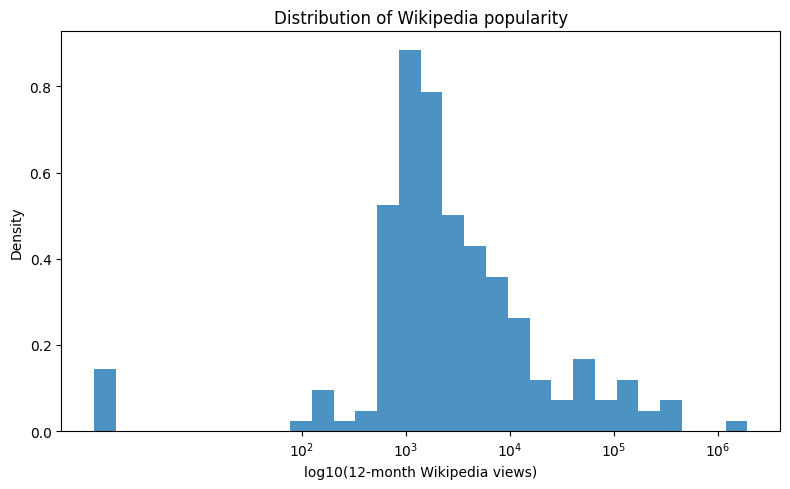

In [58]:
import numpy as np
import matplotlib.pyplot as plt

popularity = (
    df_wiki.drop_duplicates("taxonid")["popularity"]
    .clip(lower=1)
)

log_views = np.log10(popularity)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    log_views,
    bins=30,
    density=True,
    alpha=0.8,
)

ax.set_xlabel("log10(12-month Wikipedia views)")
ax.set_ylabel("Density")
ax.set_title("Distribution of Wikipedia popularity")

# nicer tick labels
ticks = [2, 3, 4, 5, 6]
ax.set_xticks(ticks)
ax.set_xticklabels([f"$10^{t}$" for t in ticks])

plt.tight_layout()
plt.show()

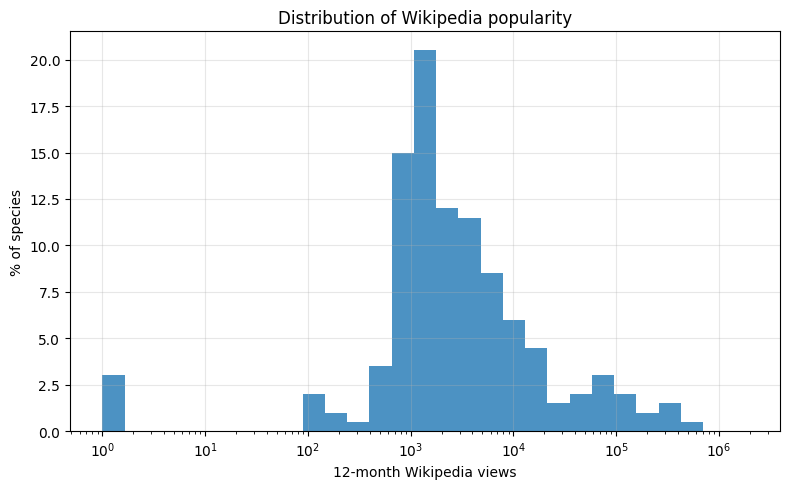

In [59]:
import numpy as np
import matplotlib.pyplot as plt

popularity = (
    df_wiki.drop_duplicates("taxonid")["popularity"]
    .clip(lower=1)
)

bins = np.logspace(
    np.log10(popularity.min()),
    np.log10(popularity.max()),
    30
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    popularity,
    bins=bins,
    weights=np.full(len(popularity), 100 / len(popularity)),
    alpha=0.8,
)

ax.set_xscale("log")
ax.set_xlabel("12-month Wikipedia views")
ax.set_ylabel("% of species")
ax.set_title("Distribution of Wikipedia popularity")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

count    2.000000e+02
mean     2.763822e+04
std      1.450649e+05
min      1.000000e+00
50%      2.153000e+03
75%      6.614000e+03
90%      4.342260e+04
95%      1.233199e+05
99%      3.891255e+05
max      1.908806e+06
Name: popularity, dtype: float64


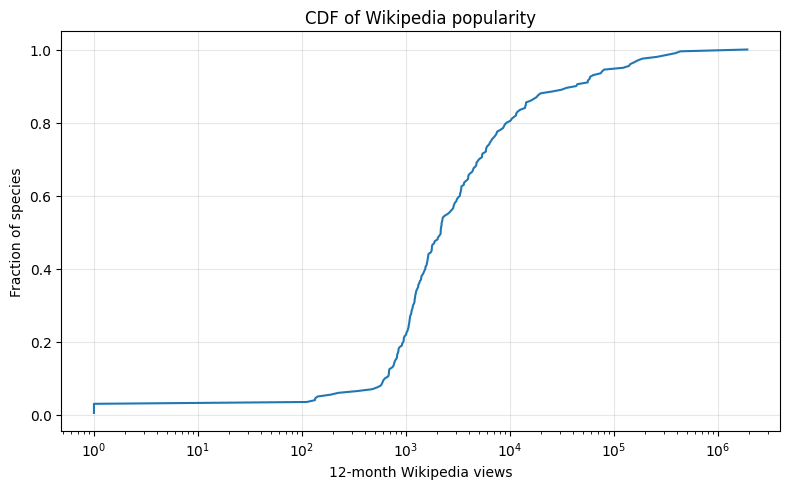

In [60]:
import numpy as np
import matplotlib.pyplot as plt

popularity = (
    df_wiki.drop_duplicates("taxonid")["popularity"]
    .clip(lower=1)
    .sort_values()
)

y = np.arange(1, len(popularity) + 1) / len(popularity)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(popularity, y)

ax.set_xscale("log")
ax.set_xlabel("12-month Wikipedia views")
ax.set_ylabel("Fraction of species")
ax.set_title("CDF of Wikipedia popularity")

ax.grid(alpha=0.3)

print(popularity.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

plt.tight_layout()
plt.show()

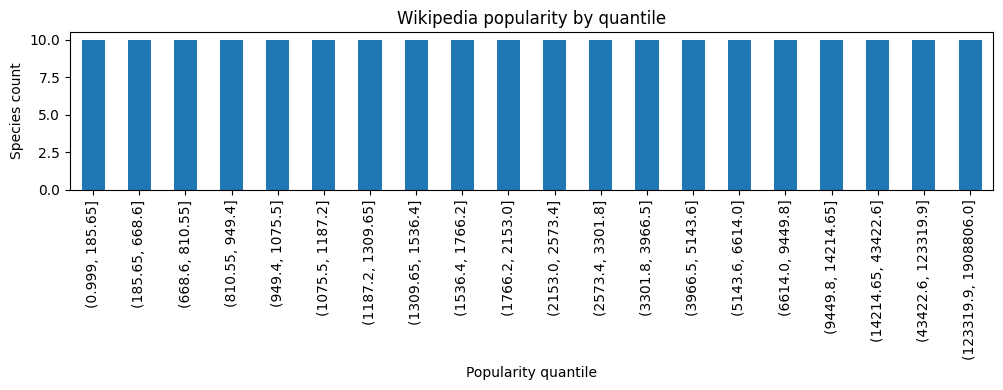

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

popularity = (
    df_wiki.drop_duplicates("taxonid")["popularity"]
    .clip(lower=1)
)

q = pd.qcut(popularity, q=20)

counts = q.value_counts(sort=False)

fig, ax = plt.subplots(figsize=(10, 4))

counts.plot.bar(ax=ax)

ax.set_ylabel("Species count")
ax.set_xlabel("Popularity quantile")
ax.set_title("Wikipedia popularity by quantile")

plt.tight_layout()
plt.show()

---
## 5 · Label selection & GeoJSON export

In [41]:
# Label: prefer main_common_name, fall back to scientific_name, then IUCN taxon ID.
common_label = df_wiki["main_common_name"].notna() & (df_wiki["main_common_name"] != "")
scientific_label = df_wiki["scientific_name"].notna() & (df_wiki["scientific_name"] != "")
df_wiki["label"] = "IUCN taxon " + df_wiki["taxonid"].astype(str)
df_wiki.loc[scientific_label, "label"] = df_wiki.loc[scientific_label, "scientific_name"]
import re as _re
def _title_fix(s):
    return _re.sub(r"'(\w)", lambda m: "'" + m.group(1).lower(), str(s).title())
df_wiki.loc[common_label, "label"] = df_wiki.loc[common_label, "main_common_name"].map(_title_fix)

# Drop species with 0 views (no Wikipedia presence → won't render usefully)
_pre_pop_ids = set(df_wiki["taxonid"].astype(int))
df_wiki = df_wiki[df_wiki.popularity > 0]

# Disambiguate labels shared by multiple distinct taxa (same common name, different species)
_label_counts = df_wiki.drop_duplicates(subset="taxonid").groupby("label")["taxonid"].count()
_ambiguous = set(_label_counts[_label_counts > 1].index)
if _ambiguous:
    _mask = df_wiki["label"].isin(_ambiguous) & df_wiki["scientific_name"].notna()
    df_wiki.loc[_mask, "label"] = (
        df_wiki.loc[_mask, "label"] + " (" + df_wiki.loc[_mask, "scientific_name"] + ")"
    )
    print(f"Disambiguated {df_wiki.loc[_mask, 'taxonid'].nunique()} taxa sharing a common label: {sorted(_ambiguous)}")
ph.log_dropped(dropped_log, _pre_pop_ids, df_wiki["taxonid"].astype(int), "zero_popularity",
            "0 Wikipedia pageviews over the last 12 months", df)
print(f"  dropped_log total: {len(dropped_log)} taxa")

print(f"Final taxon count: {df_wiki.taxonid.nunique():,}")
print(f"Final points count: {len(df_wiki):,}")

  dropped_log total: 0 taxa
Final taxon count: 200
Final points count: 211


In [42]:
# Build lightweight centroid GeoJSON used by the browser
features = []
required_geojson_cols = {"lon", "lat"}
missing_geojson_cols = required_geojson_cols - set(df_wiki.columns)
if missing_geojson_cols:
    raise RuntimeError(f"Missing centroid coordinate columns before GeoJSON export: {sorted(missing_geojson_cols)}. Rerun the spatial centroid merge cell before exporting.")
for _, row in df_wiki.iterrows():
    lon = clean_json_value(row["lon"])
    lat = clean_json_value(row["lat"])
    if lon is None or lat is None:
        continue
    props = feature_properties(row)
    features.append({
        "type": "Feature",
        "geometry": {
            "type": "Point",
            "coordinates": [round(float(lon), 4), round(float(lat), 4)]
        },
        "properties": props
    })

geojson = {"type": "FeatureCollection", "features": features}

with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(geojson, f, ensure_ascii=False)

size_mb = os.path.getsize(OUTPUT_PATH) / 1e6
unique_taxa = len({f["properties"]["taxonid"] for f in features if (f.get("properties") or {}).get("taxonid") is not None})
print(f"Written: {OUTPUT_PATH} — {unique_taxa:,} taxa, {len(features):,} features, {size_mb:.1f} MB")
print(f"Run the merge cell to combine all per-mode files into {MERGED_OUTPUT_PATH}")



Written: data/processed/animals_sample_mammals.geojson — 200 taxa, 211 features, 0.6 MB
Run the merge cell to combine all per-mode files into animals.geojson


In [43]:
# Export dropped animals log for this mode
if dropped_log:
    dropped_df = pd.DataFrame(dropped_log)
    # Deduplicate: if a taxon was logged at multiple stages, keep the first (earliest) stage
    dropped_df = dropped_df.drop_duplicates(subset="taxonid", keep="first")
    os.makedirs(os.path.dirname(DROPPED_LOG_PATH), exist_ok=True)
    dropped_df.to_csv(DROPPED_LOG_PATH, index=False)
    print(f"Dropped log: {DROPPED_LOG_PATH} — {len(dropped_df):,} taxa")
    print(dropped_df.groupby('drop_stage')['taxonid'].count().to_string())
else:
    print("No dropped taxa recorded")

No dropped taxa recorded


### Merge result files

Combines all `animals_{mode}.geojson` files from `data/processed/` into the single `animals.geojson` file loaded by the globe.

In [44]:
import glob as _glob

per_mode_files = sorted(_glob.glob("data/processed/animals_*.geojson"))
if not per_mode_files:
    raise RuntimeError("No per-mode animals files found in data/processed/. Run the export cell for at least one mode.")

all_features = []
seen_taxon_centroids = set()
for path in per_mode_files:
    with open(path, encoding="utf-8") as f:
        gj = json.load(f)
    mode_features = gj.get("features", [])
    all_features.extend(mode_features)
    print(f"  {os.path.basename(path)}: {len(mode_features):,} features")

merged = {"type": "FeatureCollection", "features": all_features}
with open(MERGED_OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(merged, f, ensure_ascii=False)

size_mb = os.path.getsize(MERGED_OUTPUT_PATH) / 1e6
unique_taxa = len({f["properties"]["taxonid"] for f in all_features if (f.get("properties") or {}).get("taxonid") is not None})
print(f"Merged {len(per_mode_files)} files → {MERGED_OUTPUT_PATH}: {unique_taxa:,} taxa, {len(all_features):,} features, {size_mb:.1f} MB")

  animals_sample_birds.geojson: 224 features
  animals_sample_fish.geojson: 211 features
  animals_sample_mammals.geojson: 211 features
  animals_sample_other.geojson: 207 features
Merged 4 files → animals.geojson: 794 taxa, 853 features, 2.5 MB


### Sanity check

Load `animals.geojson` and search any species by name.

In [57]:
ANIMALS_PATH = "/Users/t.boulademareuil/Documents/WORK/Experiments/globe/animals.geojson"
SEARCH_NAME = "Largescale Pupfish"  # common name, scientific name, or label

with open(ANIMALS_PATH, encoding="utf-8") as f:
    _gj = json.load(f)

records = []
for feat in _gj["features"]:
    props = dict(feat.get("properties") or {})
    coords = (feat.get("geometry") or {}).get("coordinates") or [None, None]
    props["lon"] = coords[0] if len(coords) > 0 else None
    props["lat"] = coords[1] if len(coords) > 1 else None
    records.append(props)

df_geojson = pd.DataFrame(records)
print(f"Loaded: {len(df_geojson):,} points from {df_geojson['taxonid'].nunique():,} taxa ({ANIMALS_PATH})")

_q = SEARCH_NAME.casefold()
_hits = df_geojson[
    df_geojson.get("label", pd.Series(dtype=str)).str.casefold().eq(_q) |
    df_geojson.get("main_common_name", pd.Series(dtype=str)).str.casefold().eq(_q) |
    df_geojson.get("scientific_name", pd.Series(dtype=str)).str.casefold().eq(_q)
]

if _hits.empty:
    print(f"'{SEARCH_NAME}' not found.")
else:
    _cols = [c for c in ["taxonid", "label", "scientific_name", "category_iucn", "taxon_group",
             "centroid_rank", "popularity", "image_source", "image_url", "wiki_url", "lat", "lon"] if c in _hits.columns]
    with pd.option_context("display.max_colwidth", 160):
        display(_hits[_cols].T if len(_hits) == 1 else _hits[_cols])
    for _, r in _hits.iterrows():
        print(f"  image ({r.get('image_source', '')}): {r.get('image_url')}")

Loaded: 853 points from 794 taxa (/Users/t.boulademareuil/Documents/WORK/Experiments/globe/animals.geojson)


,420
taxonid,6156
label,Largescale Pupfish
category_iucn,NT
taxon_group,"Fish (sharks, freshwater)"
centroid_rank,1
popularity,787
image_source,Wikidata P18
image_url,https://commons.wikimedia.org/wiki/Special:FilePath/Cyprinodon%20macrolepis.tif?width=800
wiki_url,https://en.wikipedia.org/wiki/Largescale_pupfish
lat,27.0445


  image (Wikidata P18): https://commons.wikimedia.org/wiki/Special:FilePath/Cyprinodon%20macrolepis.tif?width=800


In [58]:
# Check cases with the same point
df_geojson[df_geojson[['lat','lon']].duplicated()]

,taxonid,assessment_id,assessment_date,year_published,iucn_assessment_url,iucn_citation,wiki_title,wiki_language,wiki_project,wiki_url,...,observation_point_count,source_paths,spatial_citation,spatial_year,spatial_credit,iucn_dataset_citation,iucn_data_last_updated,popularity,lon,lat
167,22681562,260304431,2024-06-14T01:00:00.000+01:00,2024,https://www.iucnredlist.org/species/22681562/2...,BirdLife International 2024. Meiglyptes tukki....,Buff-necked_woodpecker,en,en.wikipedia.org,https://en.wikipedia.org/wiki/Buff-necked_wood...,...,None,BOTW_2025.gpkg,BirdLife International and Handbook of the Bir...,2024,BirdLife International and Handbook of the Bir...,IUCN 2025. The IUCN Red List of Threatened Spe...,10 October 2025,1484,101.9495,-0.1429
172,22681649,260303717,2024-06-14T01:00:00.000+01:00,2024,https://www.iucnredlist.org/species/22681649/2...,BirdLife International 2024. Psilopogon henric...,Yellow-crowned_barbet,en,en.wikipedia.org,https://en.wikipedia.org/wiki/Yellow-crowned_b...,...,None,BOTW_2025.gpkg,BirdLife International and Handbook of the Bir...,2009,BirdLife International and Handbook of the Bir...,IUCN 2025. The IUCN Red List of Threatened Spe...,10 October 2025,1341,101.9495,-0.1429
192,22682485,177973137,2020-06-24T01:00:00.000+01:00,2020,https://www.iucnredlist.org/species/22682485/1...,BirdLife International 2020. Anorrhinus galeri...,Bushy-crested_hornbill,en,en.wikipedia.org,https://en.wikipedia.org/wiki/Bushy-crested_ho...,...,None,BOTW_2025.gpkg,BirdLife International and Handbook of the Bir...,2009,BirdLife International and Handbook of the Bir...,IUCN 2025. The IUCN Red List of Threatened Spe...,10 October 2025,3201,114.7609,1.4223
217,22682836,260303362,2024-06-14T01:00:00.000+01:00,2024,https://www.iucnredlist.org/species/22682836/2...,BirdLife International 2024. Harpactes diardii...,Diard's_trogon,en,en.wikipedia.org,https://en.wikipedia.org/wiki/Diard%27s_trogon,...,None,BOTW_2025.gpkg,BirdLife International and Handbook of the Bir...,2024,BirdLife International and Handbook of the Bir...,IUCN 2025. The IUCN Red List of Threatened Spe...,10 October 2025,2619,101.9495,-0.1429
218,22682845,221399686,2023-03-03T00:00:00.000+00:00,2023,https://www.iucnredlist.org/species/22682845/2...,BirdLife International 2023. Harpactes orrhoph...,Cinnamon-rumped_trogon,en,en.wikipedia.org,https://en.wikipedia.org/wiki/Cinnamon-rumped_...,...,None,BOTW_2025.gpkg,BirdLife International and Handbook of the Bir...,2022,BirdLife International and Handbook of the Bir...,IUCN 2025. The IUCN Red List of Threatened Spe...,10 October 2025,1936,113.6094,1.6000
257,1190,3313525,2008-01-01T00:00:00.000+00:00,2008,https://www.iucnredlist.org/species/1190/3313525,"Chen, X.-Y. & Du, L.-N. 2008. Anabarilius poly...",Anabarilius_polylepis,en,en.wikipedia.org,https://en.wikipedia.org/wiki/Anabarilius_poly...,...,None,FW_FISH_PART1.shp,"Xiao-Yong, C. & Li-Na, D. (2007)",2008,"Xiao-Yong, C. & Li-Na, D. (2007) 2008. The IUC...",IUCN 2025. The IUCN Red List of Threatened Spe...,10 October 2025,1431,102.6863,25.0661
267,2194,9341151,2010-03-31T01:00:00.000+01:00,2010,https://www.iucnredlist.org/species/2194/9341151,"Witte, F., de Zeeuw, M.P. & Brooks, E. 2010. H...",Haplochromis_brownae,en,en.wikipedia.org,https://en.wikipedia.org/wiki/Haplochromis_bro...,...,None,FW_FISH_PART2.shp,IUCN (International Union for Conservation of ...,2010,IUCN (International Union for Conservation of ...,IUCN 2025. The IUCN Red List of Threatened Spe...,10 October 2025,788,32.9051,-1.1075
268,2196,9341491,2010-03-31T01:00:00.000+01:00,2010,https://www.iucnredlist.org/species/2196/9341491,"Witte, F., de Zeeuw, M.P. & Brooks, E. 2010. H...",Haplochromis_martini,en,en.wikipedia.org,https://en.wikipedia.org/wiki/Haplochromis_mar...,...,None,FW_FISH_PART3.shp,IUCN (International Union for Conservation of ...,2010,IUCN (International Union for Conservation of ...,IUCN 2025. The IUCN Red List of Threatened Spe...,10 October 2025,1052,32.9057,-1.1028
269,2197,934

In [60]:
df_geojson.columns

Index(['taxonid', 'assessment_id', 'assessment_date', 'year_published',
       'iucn_assessment_url', 'iucn_citation', 'wiki_title', 'wiki_language',
       'wiki_project', 'wiki_url', 'wikidata_url', 'wikidata_image_url',
       'wiki_lookup_taxonid', 'wiki_lookup_source', 'wikipedia_thumbnail_url',
       'commons_image_url', 'commons_image_page_url', 'commons_image_title',
       'commons_image_author', 'commons_image_license',
       'commons_image_license_url', 'commons_image_credit',
       'commons_image_search_source', 'commons_image_search_term', 'image_url',
       'image_source', 'image_lookup_taxonid', 'image_lookup_source', 'label',
       'category_iucn', 'population_trend', 'number_of_mature_individuals',
       'estimated_area_of_occupancy', 'estimated_extent_of_occurrence',
       'taxon_class', 'taxon_group', 'taxon_rank', 'parent_taxonid',
       'child_infrarank_taxonids', 'iucn_has_ranges', 'iucn_has_points',
       'centroid_source', 'centroid_rank', 'centroid_cou